**Descrizione del Problema**

Una grande azienda, chiamata XYZ, impiega in qualsiasi momento circa 4000 dipendenti. Tuttavia, ogni anno circa il 15% dei suoi dipendenti lascia l’azienda e deve essere sostituito con nuovo personale proveniente dal mercato del lavoro. Il management ritiene che questo livello di turnover (dipendenti che se ne vanno, volontariamente o perché licenziati) sia dannoso per l’azienda, per i seguenti motivi:

*   I progetti dei dipendenti che se ne vanno subiscono ritardi, rendendo difficile rispettare le tempistiche, con conseguente perdita di reputazione tra clienti e partner.
*   È necessario mantenere un reparto considerevole dedicato al reclutamento di nuovo personale.
*   Spesso i nuovi dipendenti devono essere formati per svolgere il lavoro e/o devono avere tempo per ambientarsi nell’azienda.

Per questo motivo, il management ha incaricato una società di HR analytics di capire su quali fattori concentrarsi per ridurre il turnover. In altre parole, vogliono sapere quali cambiamenti apportare al luogo di lavoro affinché la maggior parte dei dipendenti rimanga. Inoltre, vogliono sapere quali variabili sono più importanti e devono essere affrontate immediatamente.

**Obiettivo del caso di studio**

È richiesto di modellare la probabilità di turnover (attrition) utilizzando una regressione logistica. I risultati ottenuti saranno utilizzati dal management per comprendere quali cambiamenti apportare al luogo di lavoro per trattenere la maggior parte dei dipendenti.

##Info Datas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
employee = pd.read_csv('/content/drive/MyDrive/Datasets/employee_survey_data.csv')
general = pd.read_csv('/content/drive/MyDrive/Datasets/general_data.csv')
manager = pd.read_csv('/content/drive/MyDrive/Datasets/manager_survey_data.csv')
indep = pd.read_csv('/content/drive/MyDrive/Datasets/in_time.csv')
outdep = pd.read_csv('/content/drive/MyDrive/Datasets/out_time.csv')

In [4]:
general.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,...,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,...,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,...,1.0,Y,15,8,3,5.0,2,5,0,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,...,3.0,Y,11,8,3,13.0,5,8,7,5
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,...,4.0,Y,12,8,2,9.0,2,6,0,4


In [5]:
general.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

In [6]:
general.describe()

,Age,DistanceFromHome,Education,EmployeeCount,EmployeeID,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
count,4410.000000,4410.000000,4410.000000,4410.0,4410.000000,4410.000000,4410.000000,4391.000000,4410.000000,4410.0,4410.000000,4401.000000,4410.000000,4410.000000,4410.000000,4410.000000
mean,36.923810,9.192517,2.912925,1.0,2205.500000,2.063946,65029.312925,2.694830,15.209524,8.0,0.793878,11.279936,2.799320,7.008163,2.187755,4.123129
std,9.133301,8.105026,1.023933,0.0,1273.201673,1.106689,47068.888559,2.498887,3.659108,0.0,0.851883,7.782222,1.288978,6.125135,3.221699,3.567327
min,18.000000,1.000000,1.000000,1.0,1.000000,1.000000,10090.000000,0.000000,11.000000,8.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,2.000000,2.000000,1.0,1103.250000,1.000000,29110.000000,1.000000,12.000000,8.0,0.000000,6.000000,2.000000,3.000000,0.000000,2.000000
50%,36.000000,7.000000,3.000000,1.0,2205.500000,2.000000,49190.000000,2.000000,14.000000,8.0,1.000000,10.000000,3.000000,5.000000,1.000000,3.000000
75%,43.000000,14.000000,4.000000,1.0,3307.750000,3.000000,83800.000000,4.000000,18.000000,8.0,1.000000,15.000000,3.000000,9.000000,3.000000,7.000000
max,60.000000,29.000000,5.000000,1.0,4410.000000,5.000000,199990.000000,9.000000,25.000000,8.0,3.000000,40.000000,6.000000,40.000000,15.000000,17.000000


In [7]:
general.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeID,0
Gender,0


In [8]:
general = general.dropna()
general.drop(['EmployeeCount', 'StandardHours', 'Over18'], axis=1, inplace=True)

In [9]:
numerical_columns = general.select_dtypes(include=[np.number]).columns
general[numerical_columns] = general[numerical_columns].fillna(general[numerical_columns].median())

categorical_columns = general.select_dtypes(include=['object']).columns
general[categorical_columns] = general[categorical_columns].fillna(general[categorical_columns].mode().iloc[0])

Si è scelto di utilizzare la mediana per le features numeriche perché è meno sensibile agli outliers rispetto alla media. La mediana, essendo il valore centrale, offre una misura più robusta della tendenza centrale.

Invece, per le features categoriche, si è scelta la moda perchè media e mediana forniscono dati numerici, la moda, essendo il valore più presente, ci aiuta a riempire le colonne con valori non numerici.

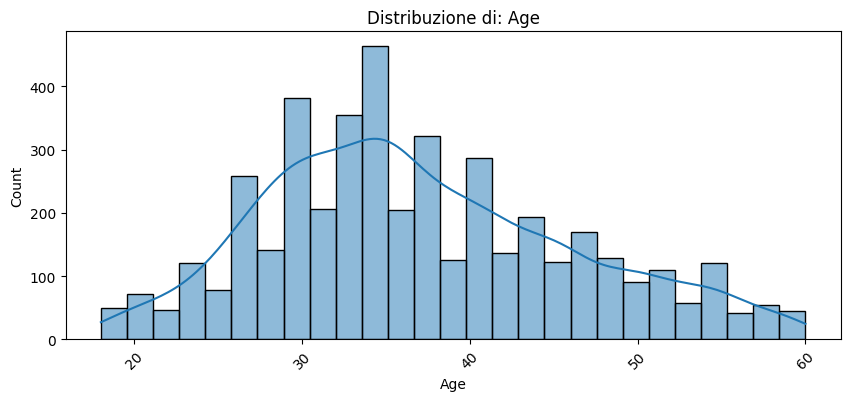

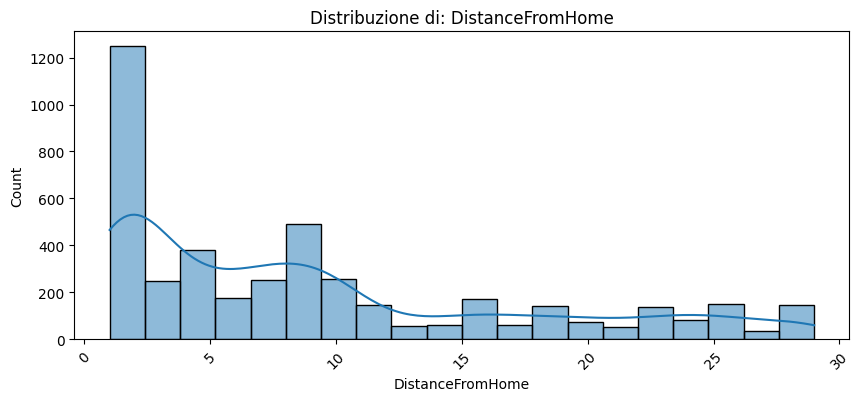

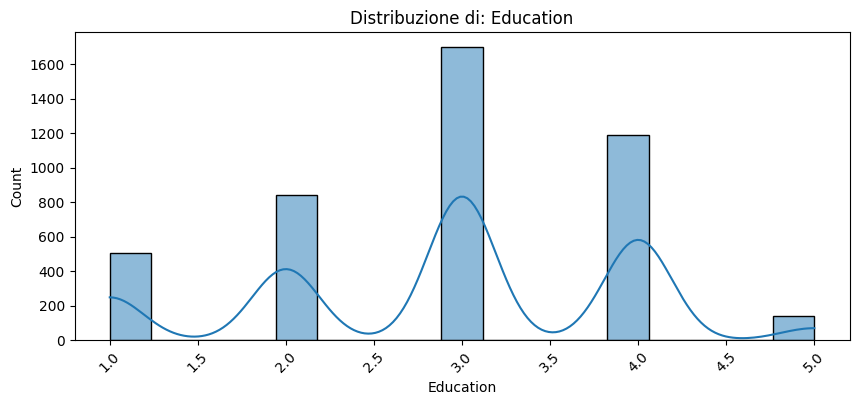

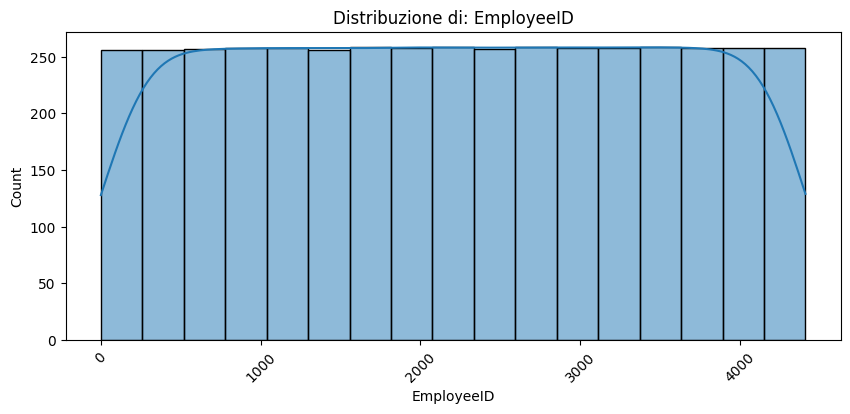

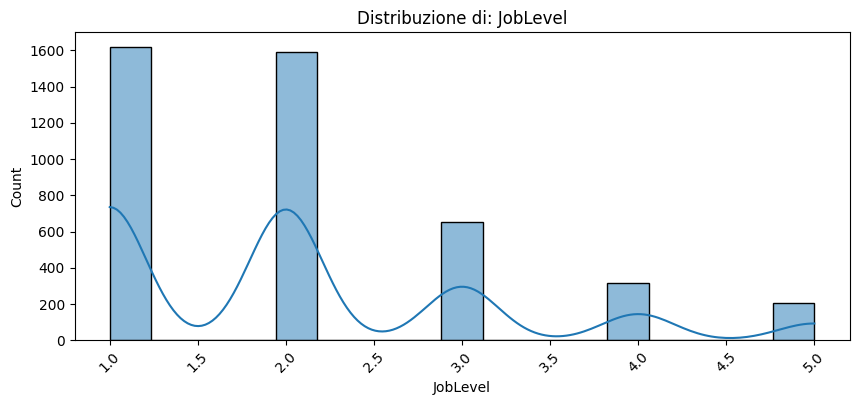

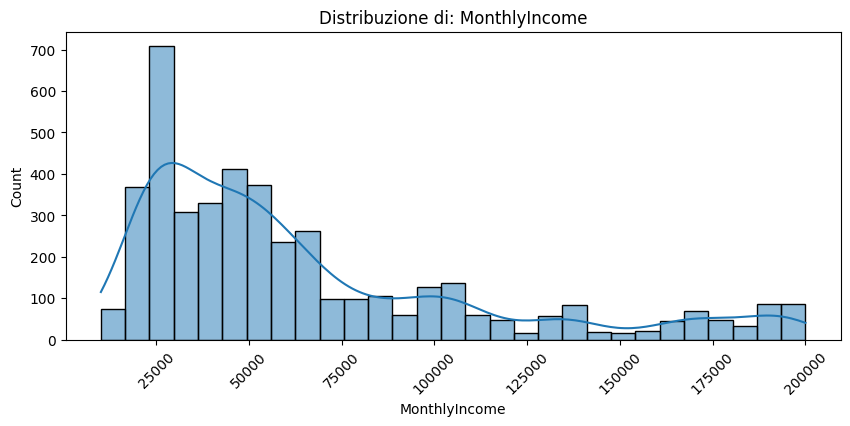

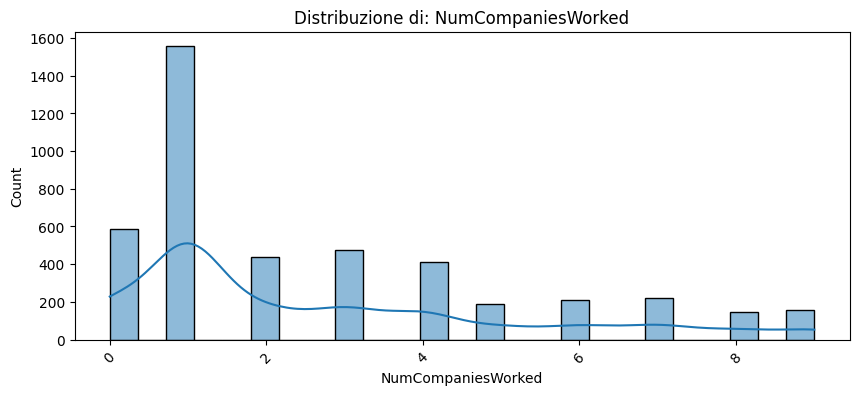

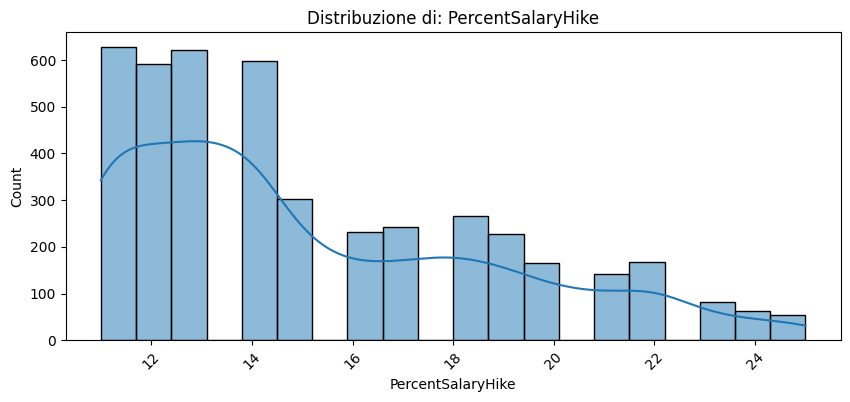

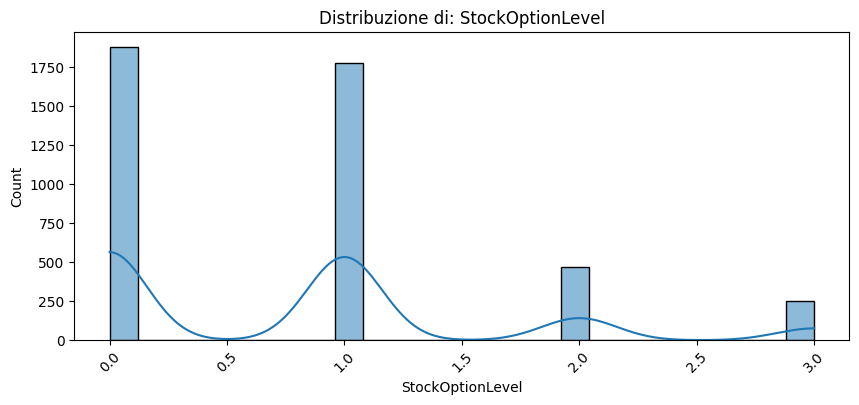

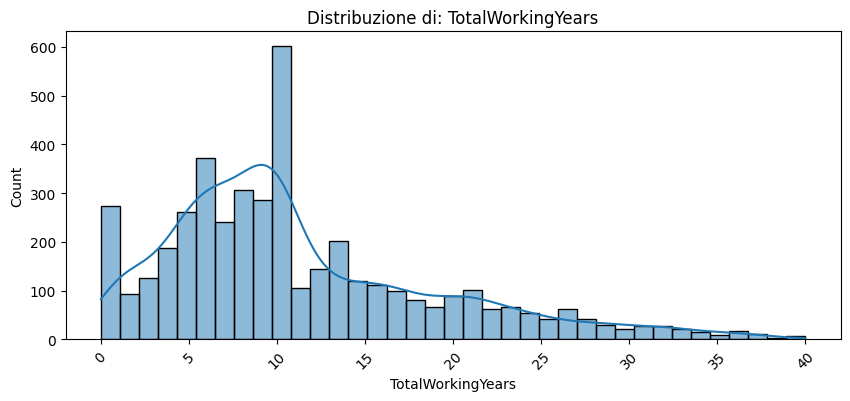

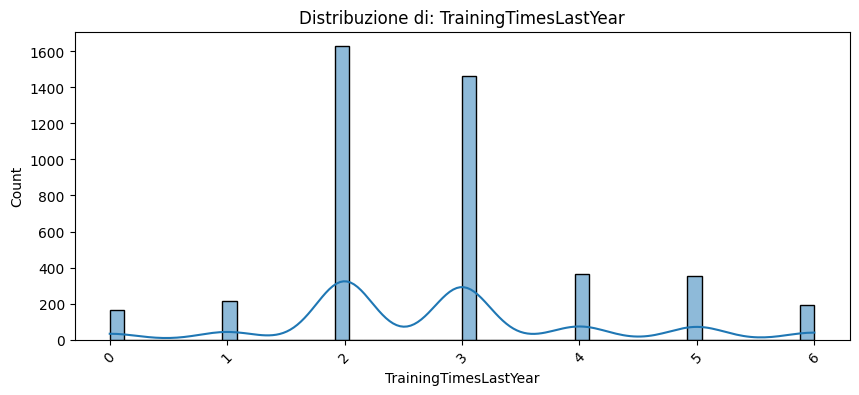

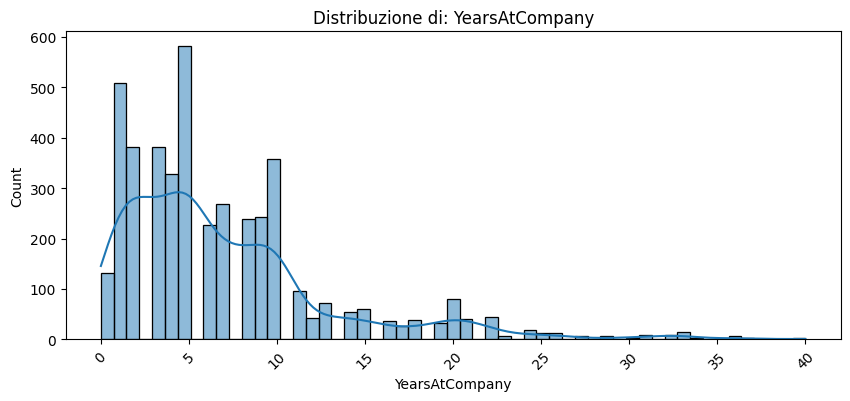

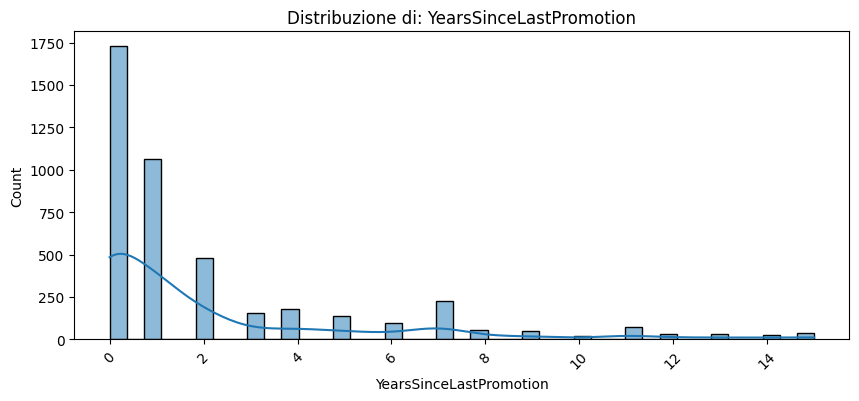

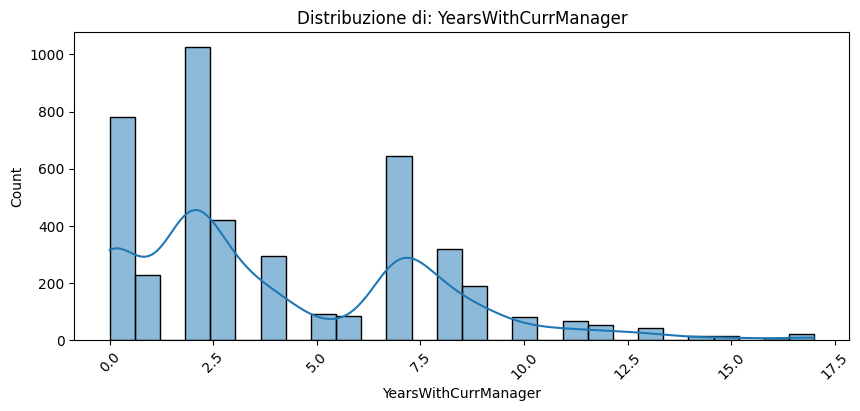

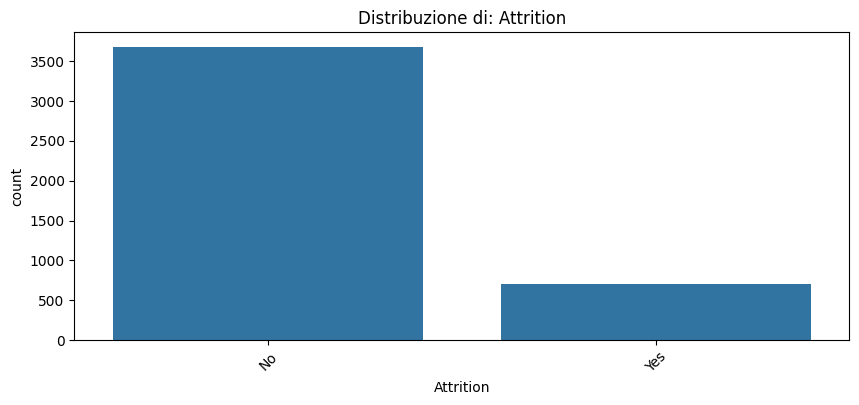

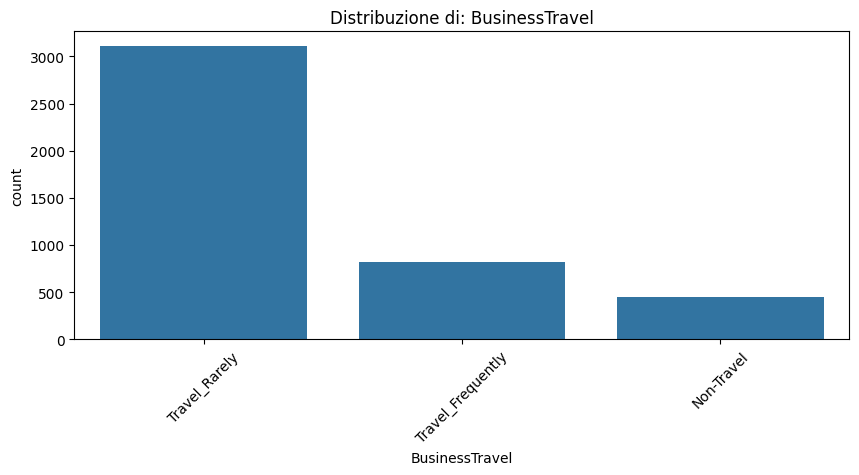

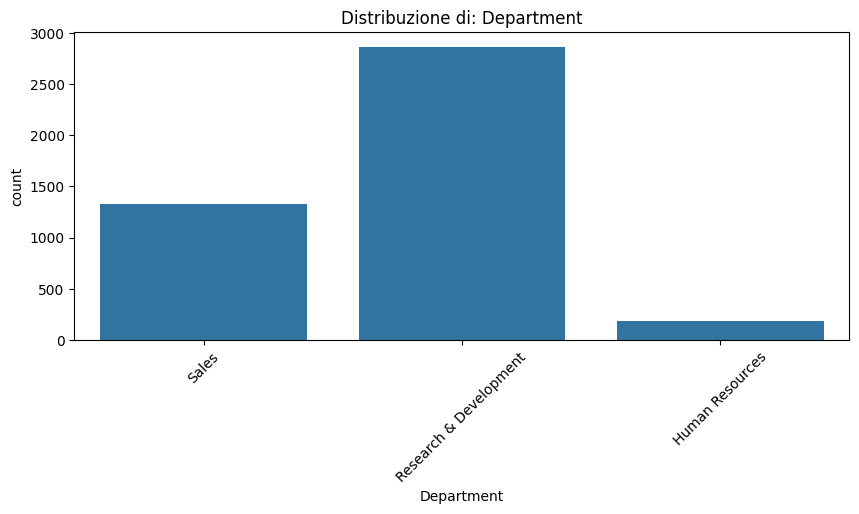

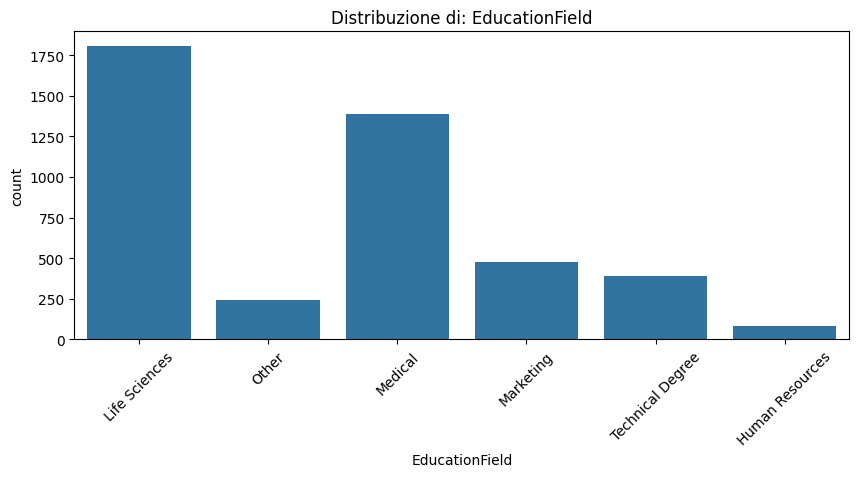

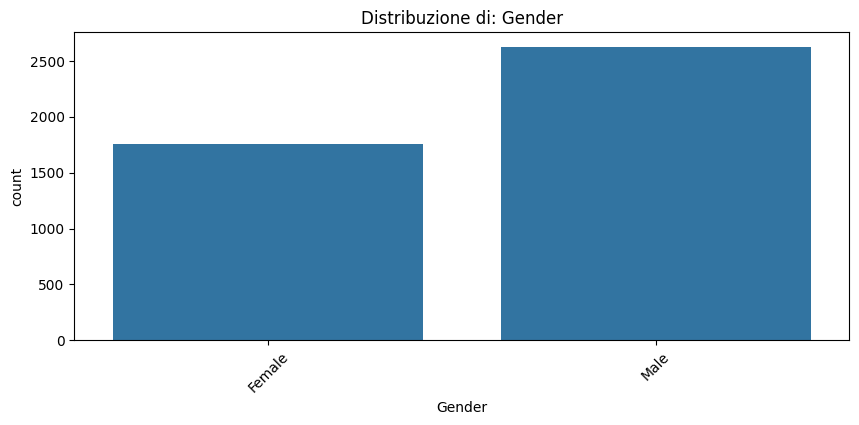

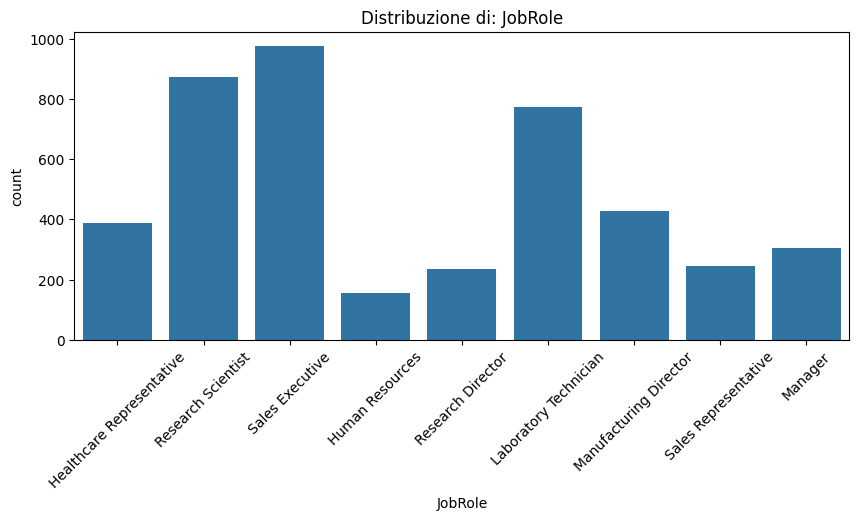

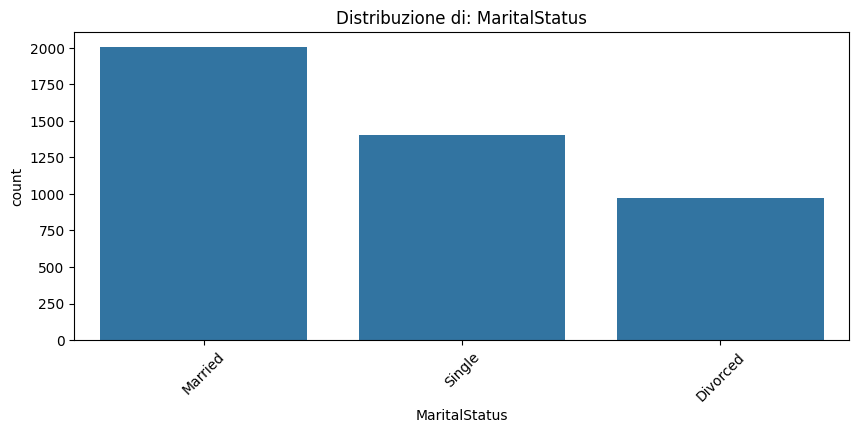

In [10]:
for column in numerical_columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(general[column], kde=True)
    plt.title(f'Distribuzione di: {column}')
    plt.xticks(rotation=45)
    plt.show()

for column in categorical_columns:
    plt.figure(figsize=(10, 4))
    sns.countplot(data=general, x=column)
    plt.title(f'Distribuzione di: {column}')
    plt.xticks(rotation=45)
    plt.show()

<Axes: >

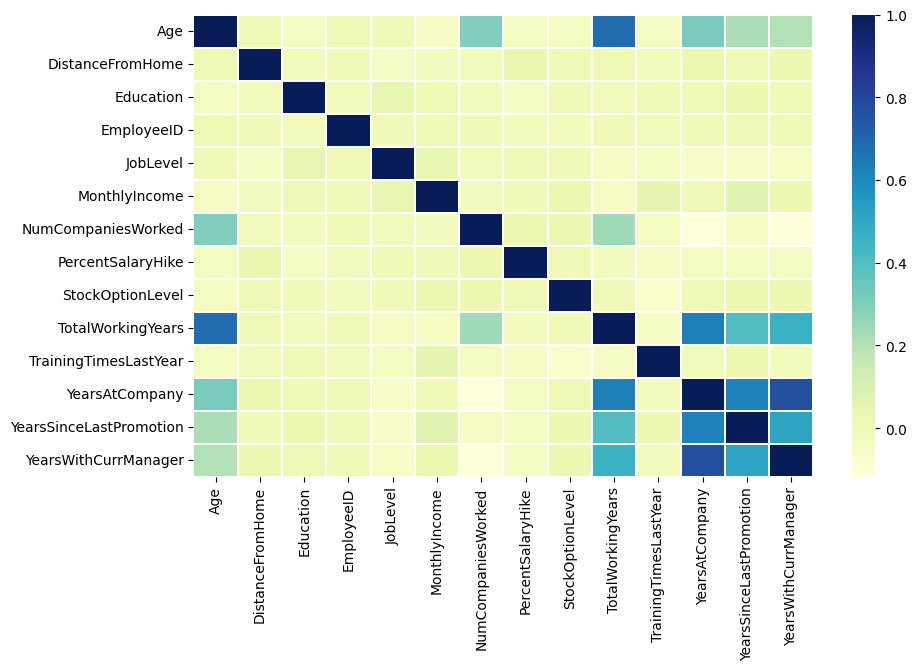

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(general.select_dtypes(include=[np.number]).corr(), cmap ="YlGnBu", linewidths = 0.1, ax = ax)

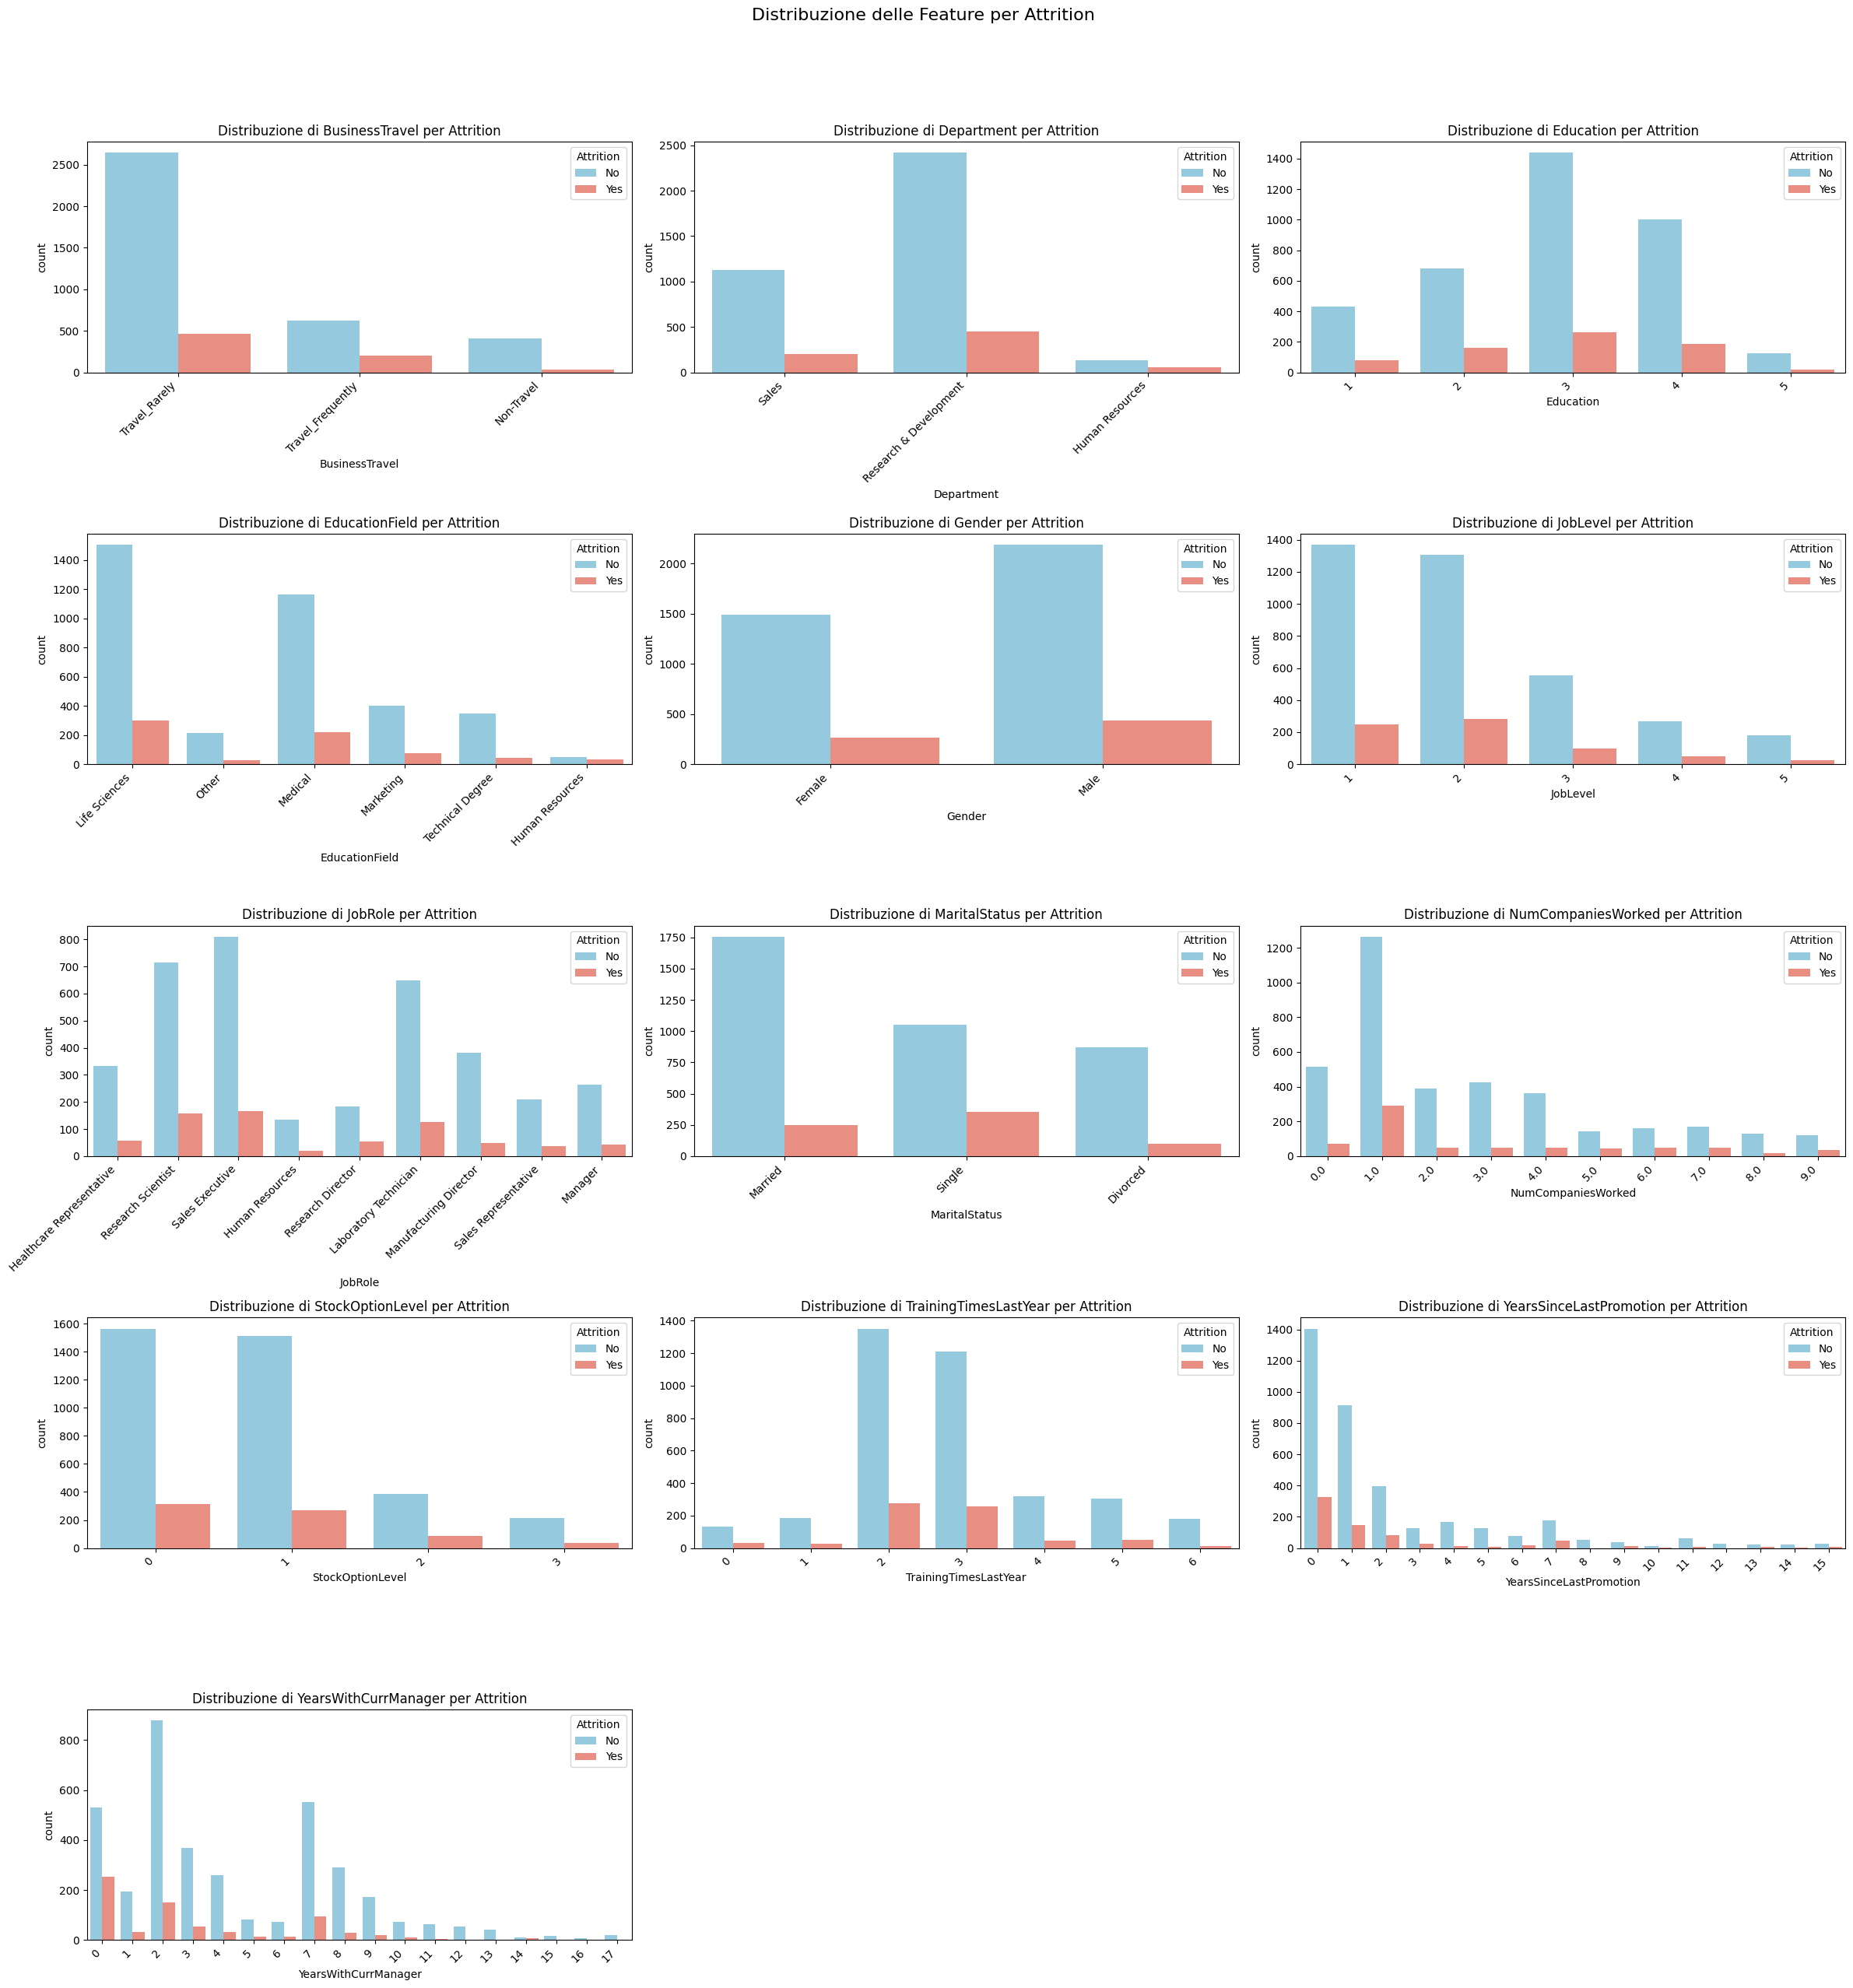

In [12]:
feature_cat = [
    'BusinessTravel',
    'Department',
    'Education',
    'EducationField',
    'Gender',
    'JobLevel',
    'JobRole',
    'MaritalStatus',
    'NumCompaniesWorked',
    'StockOptionLevel',
    'TrainingTimesLastYear',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

attrition_palette = {'No': 'skyblue', 'Yes': 'salmon'}

general['Attrition'] = pd.Categorical(general['Attrition'], categories=['No', 'Yes'], ordered=True)

rows = (len(feature_cat) + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(24, 5 * rows))
axes = axes.flatten()

for i, feature in enumerate(feature_cat):
    ax = axes[i]
    sns.countplot(x=feature, hue='Attrition', data=general, ax=ax, palette=attrition_palette)
    ax.set_title(f'Distribuzione di {feature} per Attrition')
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

for j in range(len(feature_cat), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Distribuzione delle Feature per Attrition', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Da questi grafici si evincono numerosi spunti:
1.   I dipendenti che viaggiano molto tendono ad avere un tasso di abbandono più alto rispetto a quelli che non viaggiano (o viaggiano raramente)
2.   In genere, i livelli di occupazione più bassi potrebbero registrare un tasso di abbandono più elevato poiché i dipendenti cercano di avanzare di livello, mentre i livelli di occupazione più alti tendono ad avere maggiore stabilità.
3.   I dipendenti single hanno una tendenza maggiore ad andarsene rispetto ai dipendenti sposati o divorziati, probabilmente a causa di minori legami personali con un luogo o un lavoro specifico.
4.   I dipendenti che hanno lavorato in precedenza per un numero maggiore di aziende potrebbero essere più inclini all'abbandono, il che indica una tendenza a cambiare lavoro. (Job Hopping)

Per verificare queste supposizioni, ho creato una rappresentazione tabellare dei dati, in modo da visualizzare al meglio la loro distribuzione e percentuale.





In [13]:
for feature in feature_cat:
  counts_per_group = general.groupby([feature, 'Attrition'], observed=False).size().reset_index(name='count_val')

  total_per_feature_category = general.groupby(feature, observed=False).size().reset_index(name='total_count_feature')

  merged_data = pd.merge(counts_per_group, total_per_feature_category, on=feature, how='left')
  merged_data['percentage'] = (merged_data['count_val'] / merged_data['total_count_feature']) * 100

  pivot_counts = merged_data.pivot_table(index=feature, columns='Attrition', values='count_val', fill_value=0, observed=False)
  pivot_counts.columns = [f'Count_{col}' for col in pivot_counts.columns]

  pivot_percentages = merged_data.pivot_table(index=feature, columns='Attrition', values='percentage', fill_value=0, observed=False)
  pivot_percentages.columns = [f'Percentage_{col}' for col in pivot_percentages.columns]
  pivot_percentages = pivot_percentages.round(1)

  final_pivot_table = pd.concat([pivot_counts, pivot_percentages], axis=1)

  print(f"\n--- Attrition Analysis per {feature} ---")
  print(final_pivot_table)
  print("\n")


--- Attrition Analysis per BusinessTravel ---
                   Count_No  Count_Yes  Percentage_No  Percentage_Yes
BusinessTravel                                                       
Non-Travel            412.0       36.0           92.0             8.0
Travel_Frequently     621.0      204.0           75.3            24.7
Travel_Rarely        2644.0      465.0           85.0            15.0



--- Attrition Analysis per Department ---
                        Count_No  Count_Yes  Percentage_No  Percentage_Yes
Department                                                                
Human Resources            132.0       55.0           70.6            29.4
Research & Development    2416.0      449.0           84.3            15.7
Sales                     1129.0      201.0           84.9            15.1



--- Attrition Analysis per Education ---
           Count_No  Count_Yes  Percentage_No  Percentage_Yes
Education                                                    
1             4

In [14]:
def violin_plot(cat):
  fig, ax = plt.subplots(figsize=(24,0.1))
  plt.title(cat)
  plt.axis('off')
  plt.show()

  sns.catplot(x=cat, y='Age', data=general, hue='Attrition', kind='violin', bw_method=0.2, col='Gender', inner='quartile', height=6, aspect=1.5)
  sns.catplot(x=cat, y='YearsAtCompany', data=general, hue='Attrition', kind='violin', bw_method=0.2, col='Gender', inner='quartile', height=6, aspect=1.5)
  sns.catplot(x=cat, y='MonthlyIncome', data=general, hue='Attrition', kind='violin', bw_method=0.2, col='Gender', inner='quartile', height=6, aspect=1.5)
  sns.catplot(x=cat, y='NumCompaniesWorked', data=general, hue='Attrition', kind='violin', bw_method=0.2, col='Gender', inner='quartile', height=6, aspect=1.5)

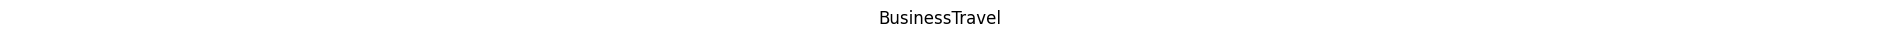

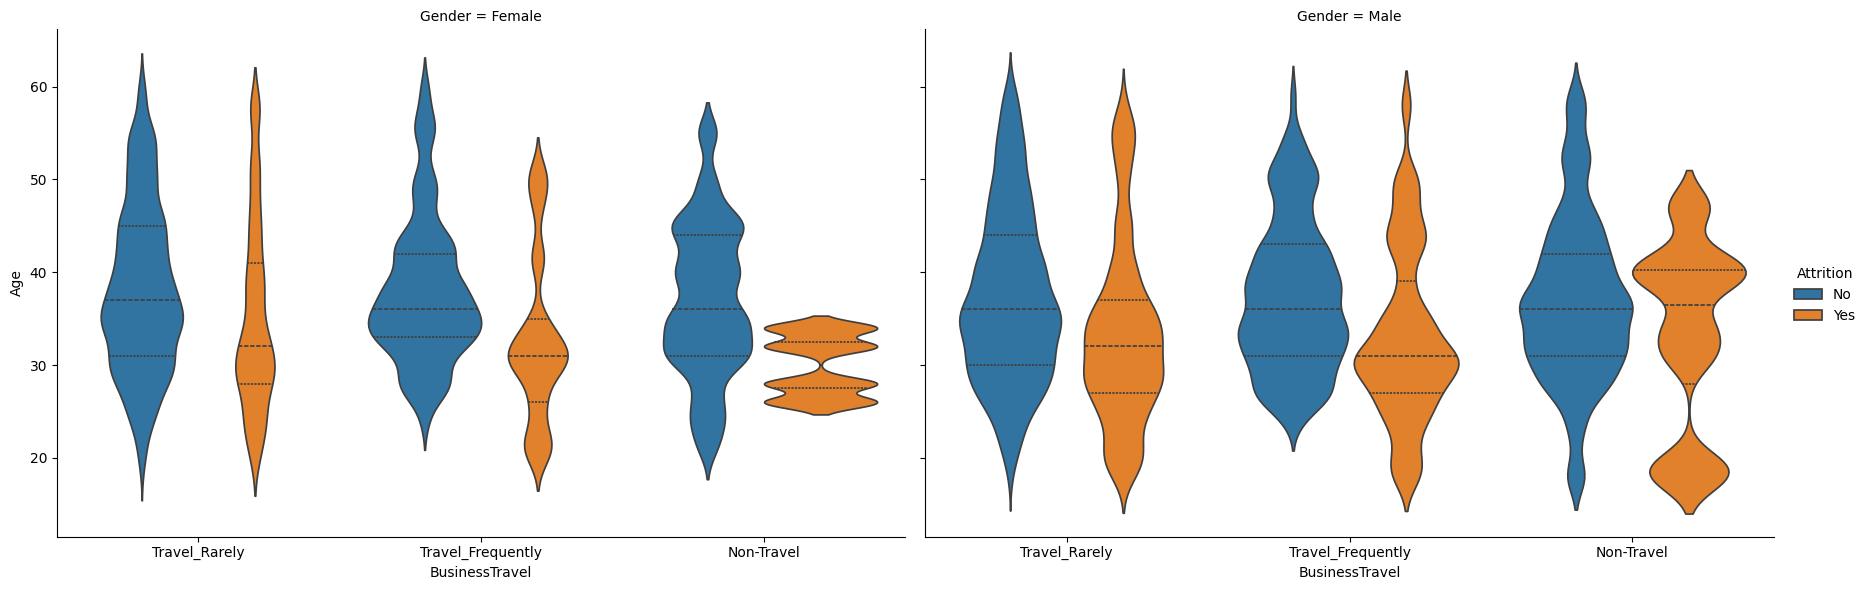

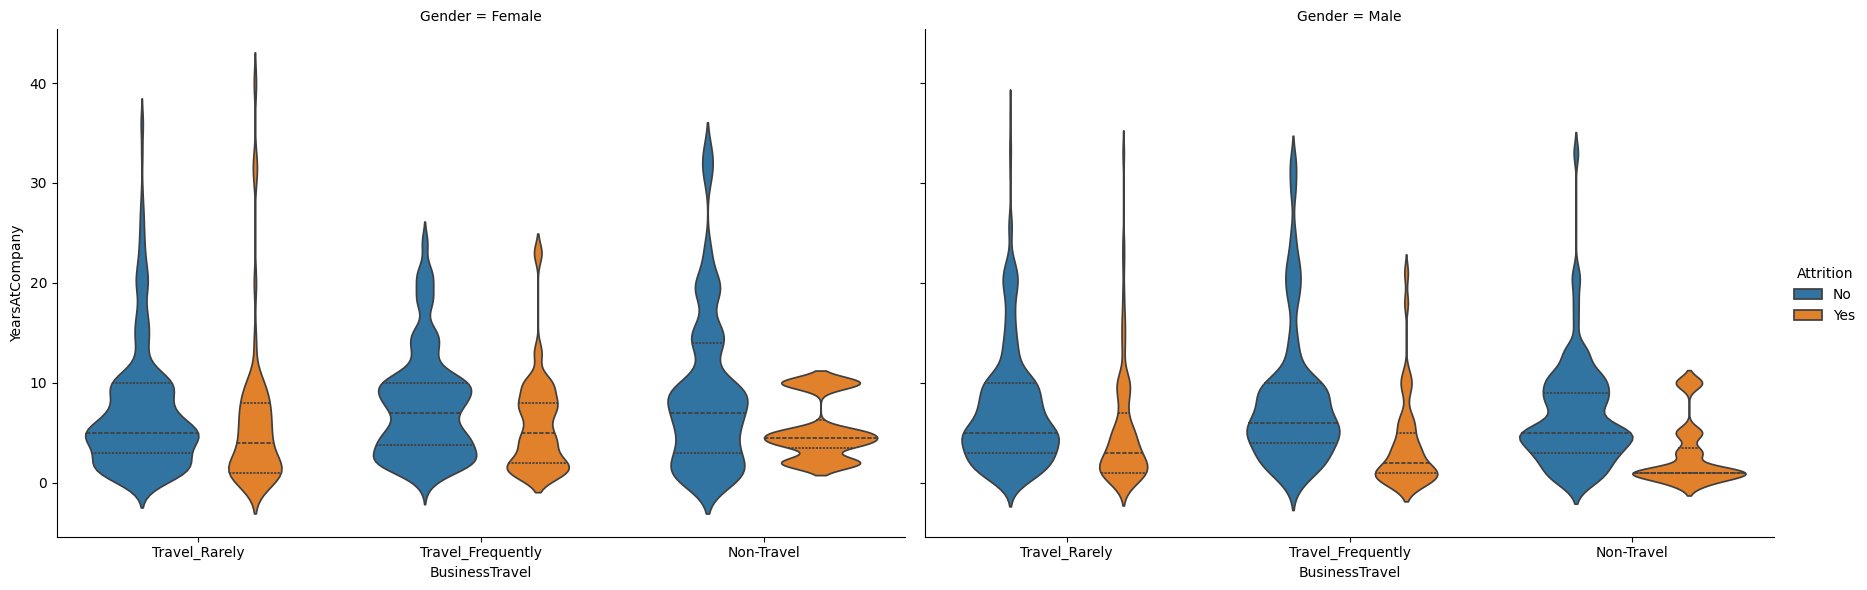

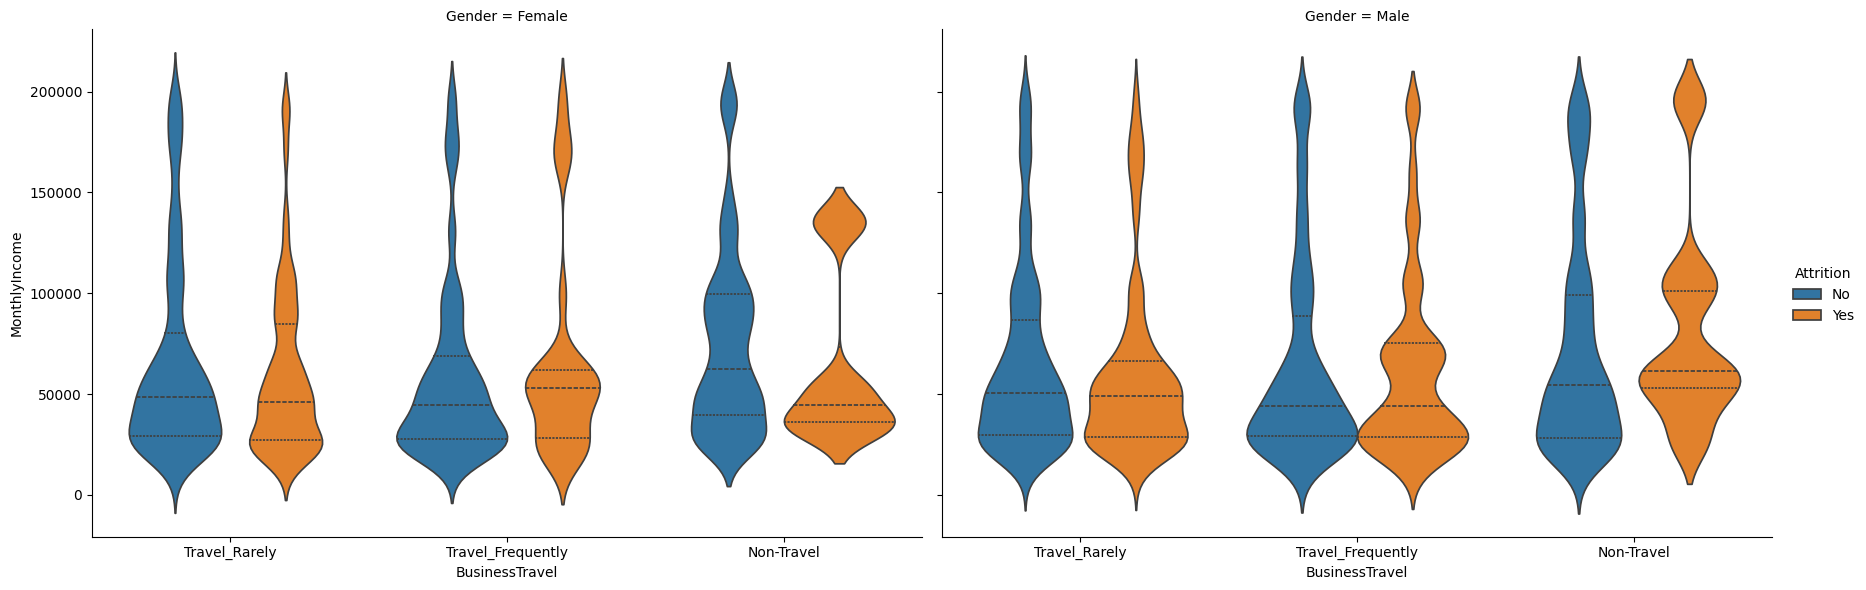

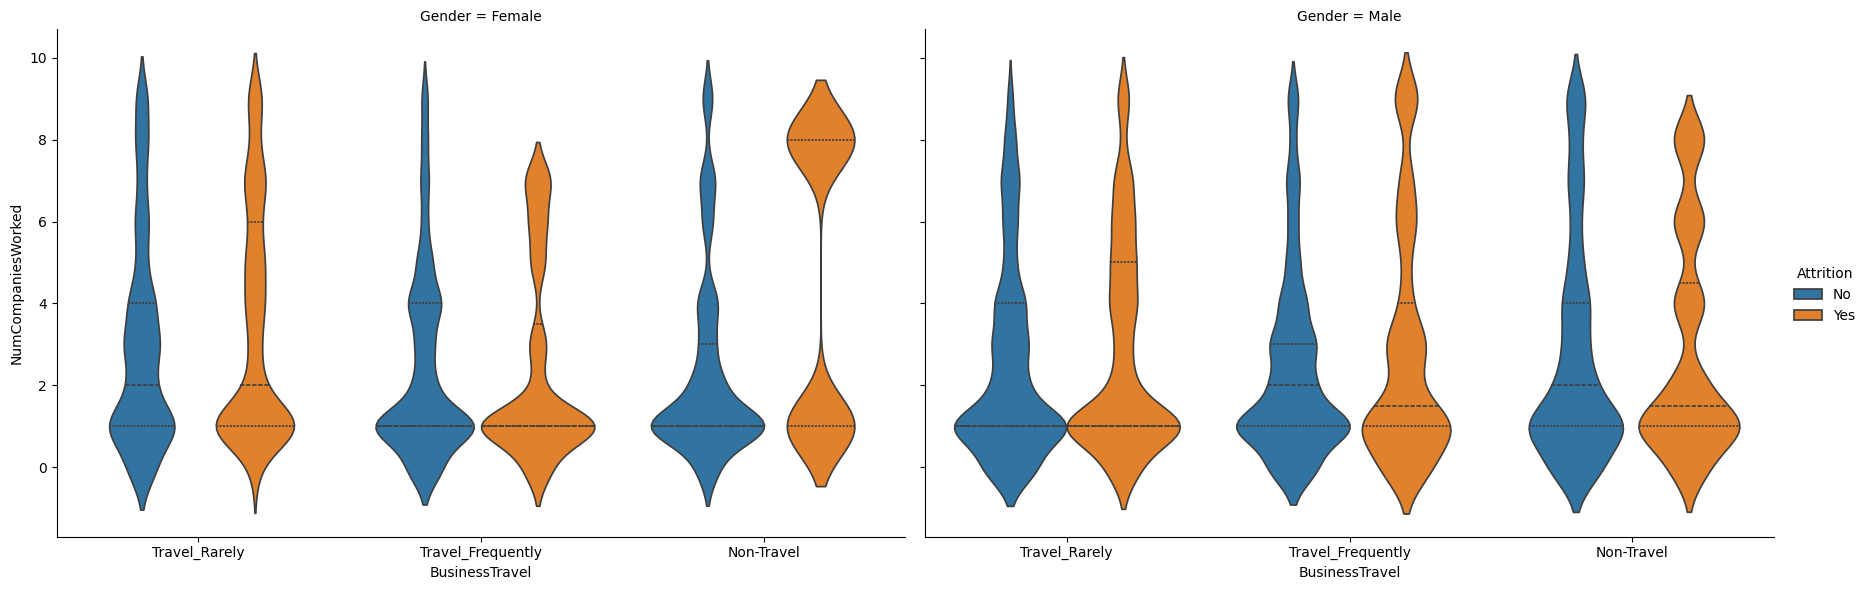

In [15]:
violin_plot('BusinessTravel')

Alcune considerazioni:
*   I dipendenti che viaggiano frequentemente e che abbandonano l'azienda tendono ad essere in media più giovani rispetto a quelli che viaggiano frequentemente ma rimangono. Tendenza rilevabile sia nelle donne che negli uomini.
*   Per chi viaggia frequentemente e abbandona, la distribuzione degli anni in azienda è spesso concentrata sui valori più bassi. Questo rafforza l'idea che i dipendenti con minore anzianità aziendale, se sottoposti a viaggi frequenti, potrebbero essere più inclini a cercare nuove opportunità.
*   Tra i dipendenti che viaggiano frequentemente e che poi abbandonano, la distribuzione degli stipendi tende ad essere inferiore rispetto a coloro che viaggiano frequentemente e rimangono. Questo potrebbe indicare che, a parità di frequenza di viaggio, un reddito percepito come insufficiente è un fattore chiave per l'abbandono.  
*   Si osserva che i dipendenti che viaggiano frequentemente e che mostrano un alto tasso di abbandono spesso presentano una distribuzione di NumCompaniesWorked con valori più elevati.



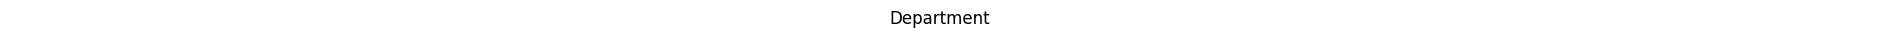

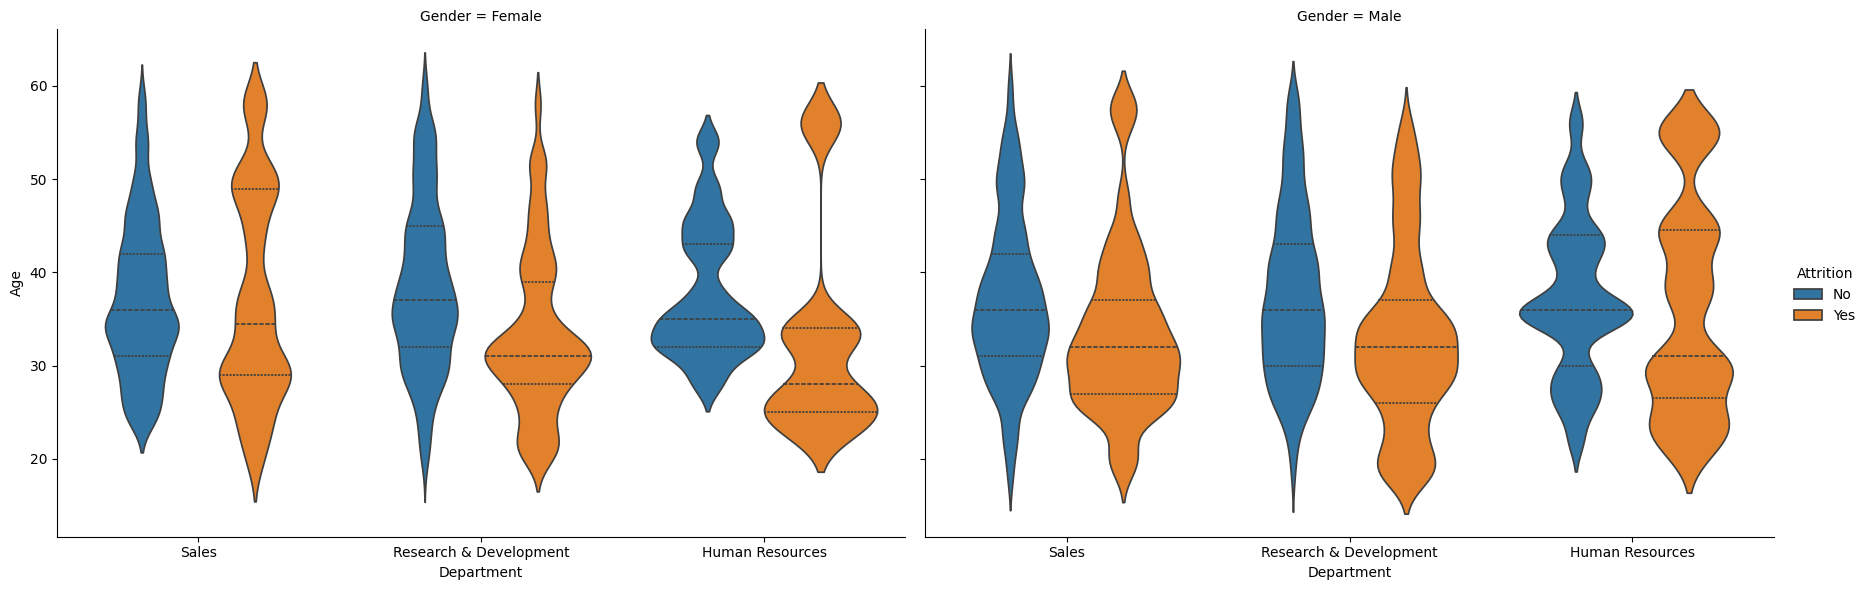

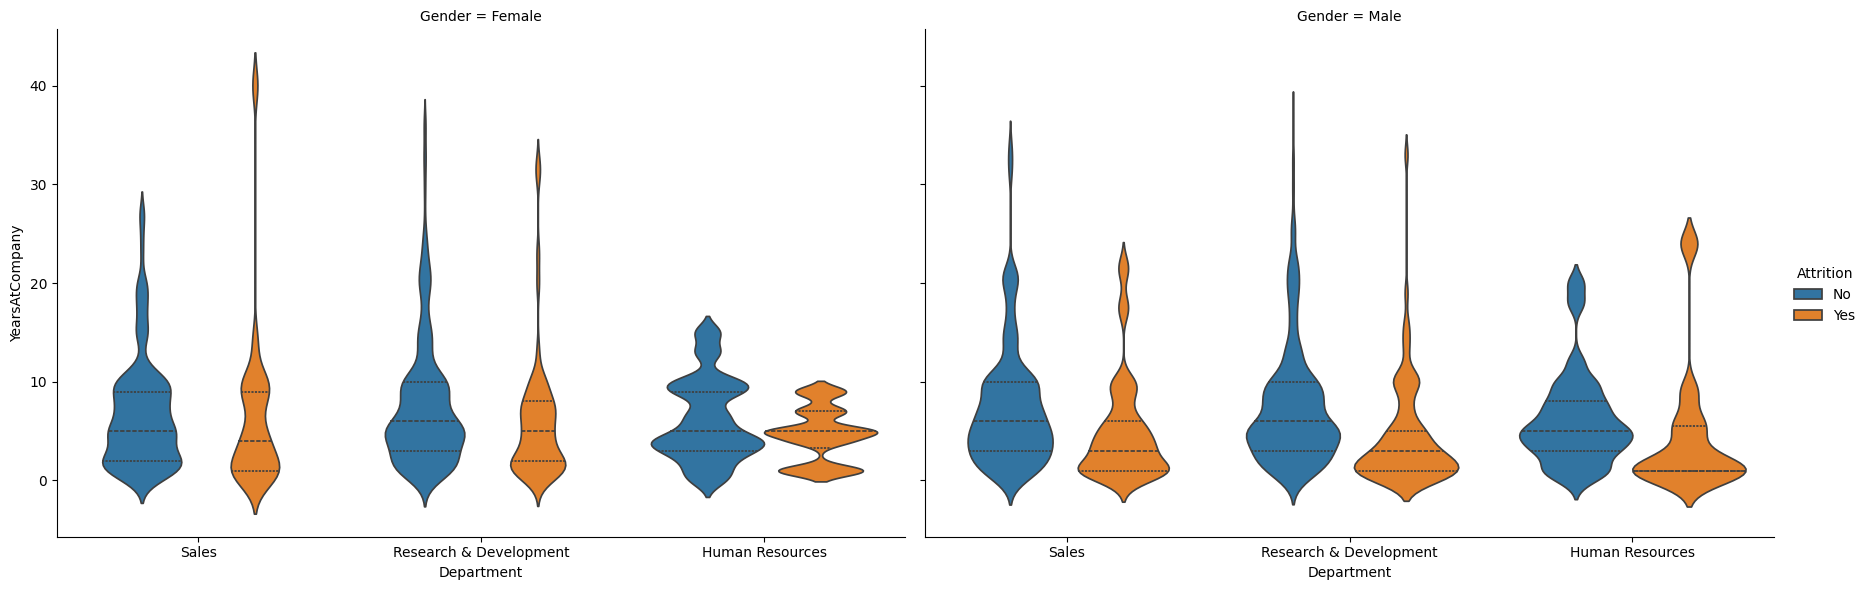

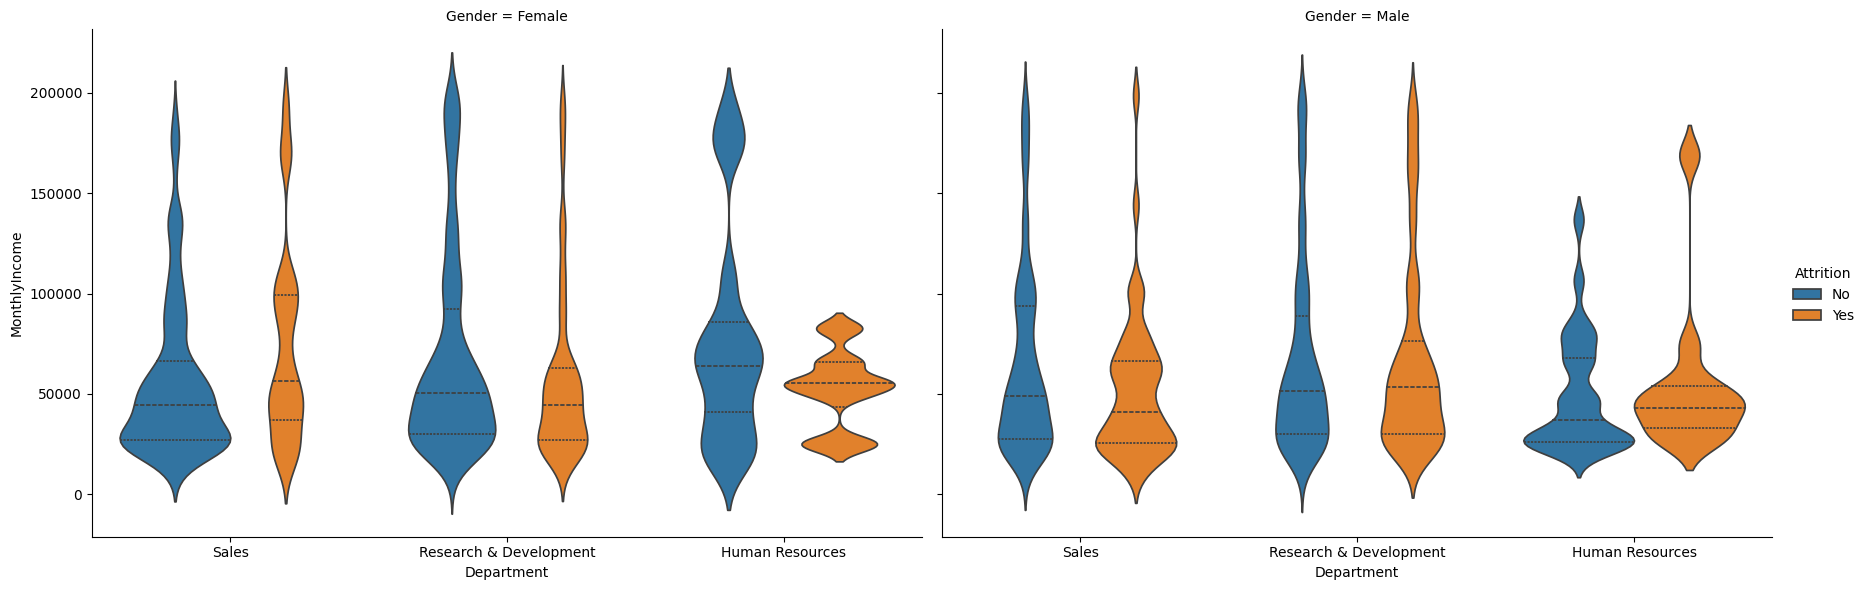

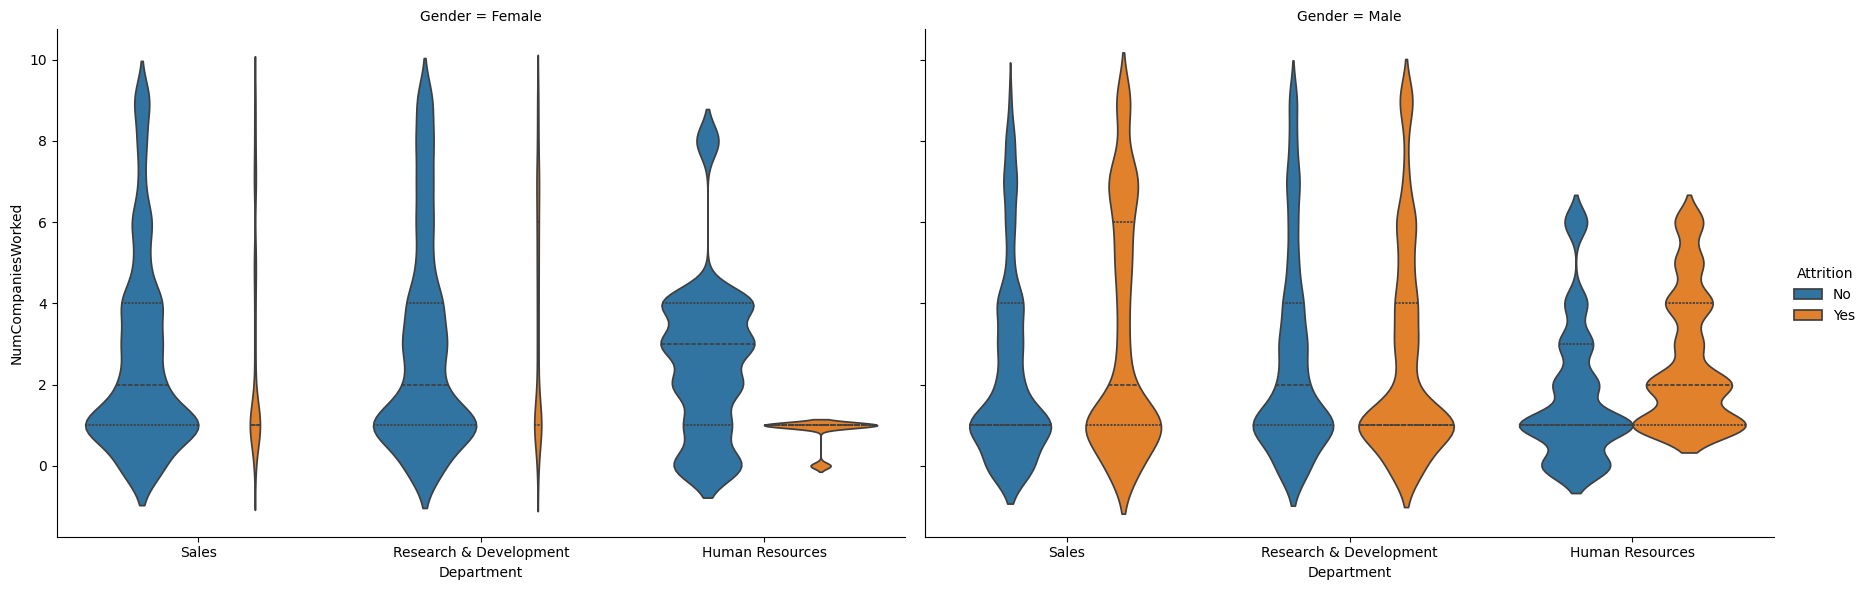

In [16]:
violin_plot('Department')

Considerazioni:
*   In dipartimenti come quello R&D, i dipendenti che abbandonano tendono ad essere più giovani di quelli che restano. In dipartimenti, invece, come Sales l'età dei dipendenti che abbandonano è più variabile e/o mostrare picchi in età matura. Potrebbe essere legato al raggiungimento di obiettivi di carriera altrove.
*   Indipendentemente dal dipartimento, chi ha pochi anni aziendali di esperienza, tende ad andarsene. Per certi dipartimenti (Sales, R&D), i violini si estendono verso l'alto, sintomo che anche se rimani per tanto anno in quella azienda, c'è probabilità comunque di abbandonarla.


Per mitigare il turnover dei dipendenti, l'azienda potrebbe intraprendere le seguenti raccomandazioni:
*   Per i lavoratori che viaggiano spesso, soprattutto i più giovani, valutare il carico di lavoro, offrire modalità di viaggio flessibili. Garantire una retribuzione competitiva per questo gruppo.
*  Creare opportunità di avanzamento di carriera chiare e visibili per i dipendenti nei livelli professionali più bassi.
*  Sviluppare programmi che rispondano ai bisogni sociali e alle preferenze dei dipendenti single, promuovendo un maggiore senso di appartenenza e di connessione con la cultura aziendale.
*  Per i dipendenti con una storia di frequenti cambi di azienda, concentrarsi su check-in precoci e frequenti per comprendere le loro aspirazioni di carriera. Offrire piani di sviluppo personalizzati, progetti stimolanti e riconoscimenti per mantenerli coinvolti e motivati.
*  Assicurare che i criteri di promozione siano trasparenti ed equi. Implementare un programma di riconoscimento robusto che valorizzi i contributi anche al di fuori delle promozioni formali. Rivedere regolarmente salari e benefit per restare competitivi e premiare lealtà e performance.



In [17]:
employee.head()

,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance
0,1,3.0,4.0,2.0
1,2,3.0,2.0,4.0
2,3,2.0,2.0,1.0
3,4,4.0,4.0,3.0
4,5,4.0,1.0,3.0


In [18]:
employee.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4410 non-null   int64  
 1   EnvironmentSatisfaction  4385 non-null   float64
 2   JobSatisfaction          4390 non-null   float64
 3   WorkLifeBalance          4372 non-null   float64
dtypes: float64(3), int64(1)
memory usage: 137.9 KB


In [19]:
employee.describe()

,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance
count,4410.000000,4385.000000,4390.000000,4372.000000
mean,2205.500000,2.723603,2.728246,2.761436
std,1273.201673,1.092756,1.101253,0.706245
min,1.000000,1.000000,1.000000,1.000000
25%,1103.250000,2.000000,2.000000,2.000000
50%,2205.500000,3.000000,3.000000,3.000000
75%,3307.750000,4.000000,4.000000,3.000000
max,4410.000000,4.000000,4.000000,4.000000


In [20]:
employee.isna().sum()

,0
EmployeeID,0
EnvironmentSatisfaction,25
JobSatisfaction,20
WorkLifeBalance,38


In [21]:
employee = employee.dropna()

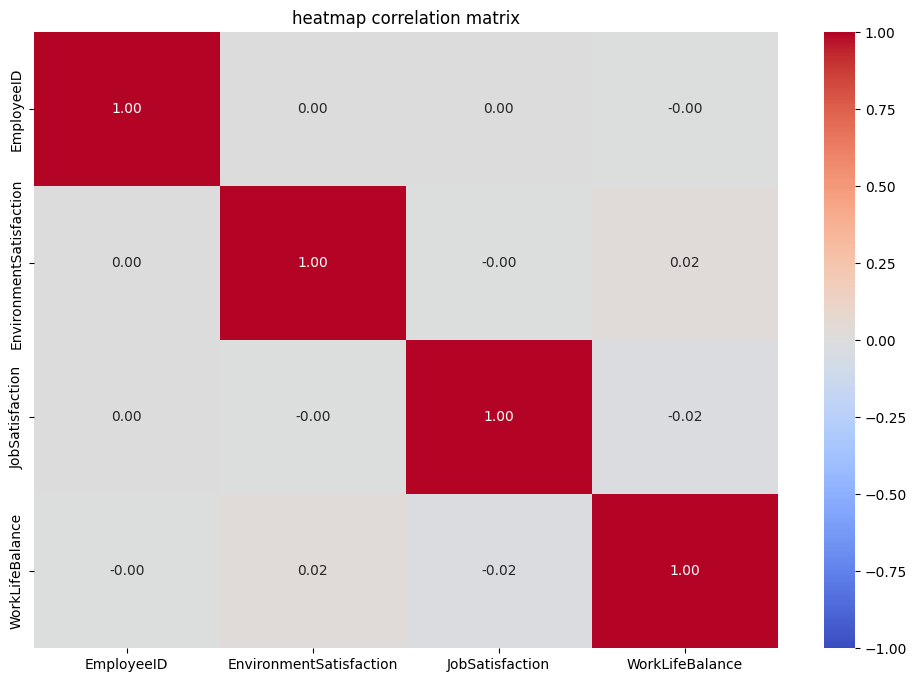

In [22]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    employee.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1
)
plt.title('heatmap correlation matrix')
plt.show()

In [23]:
manager.head()

,EmployeeID,JobInvolvement,PerformanceRating
0,1,3,3
1,2,2,4
2,3,3,3
3,4,2,3
4,5,3,3


In [24]:
manager.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   EmployeeID         4410 non-null   int64
 1   JobInvolvement     4410 non-null   int64
 2   PerformanceRating  4410 non-null   int64
dtypes: int64(3)
memory usage: 103.5 KB


In [25]:
manager.describe()

,EmployeeID,JobInvolvement,PerformanceRating
count,4410.000000,4410.000000,4410.000000
mean,2205.500000,2.729932,3.153741
std,1273.201673,0.711400,0.360742
min,1.000000,1.000000,3.000000
25%,1103.250000,2.000000,3.000000
50%,2205.500000,3.000000,3.000000
75%,3307.750000,3.000000,3.000000
max,4410.000000,4.000000,4.000000


In [26]:
manager.isna().sum()

,0
EmployeeID,0
JobInvolvement,0
PerformanceRating,0


In [27]:
df = pd.merge(general, manager, on='EmployeeID', how='inner')
df = pd.merge(df, employee, on='EmployeeID', how='inner')

In [28]:
df.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeID,Gender,JobLevel,...,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,JobInvolvement,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,Female,1,...,1.0,6,1,0,0,3,3,3.0,4.0,2.0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,2,Female,1,...,6.0,3,5,1,4,2,4,3.0,2.0,4.0
2,32,No,Travel_Frequently,Research & Development,17,4,Other,3,Male,4,...,5.0,2,5,0,3,3,3,2.0,2.0,1.0
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,4,Male,3,...,13.0,5,8,7,5,2,3,4.0,4.0,3.0
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,5,Male,1,...,9.0,2,6,0,4,3,3,4.0,1.0,3.0


In [29]:
indep.rename(columns={indep.columns[0]: 'EmployeeID'}, inplace=True)
outdep.rename(columns={outdep.columns[0]: 'EmployeeID'}, inplace=True)

indep_dates = indep.iloc[:, 1:].apply(pd.to_datetime, errors='coerce')
indep = pd.concat([indep[['EmployeeID']], indep_dates], axis=1)

outdep_dates = outdep.iloc[:, 1:].apply(pd.to_datetime, errors='coerce')
outdep = pd.concat([outdep[['EmployeeID']], outdep_dates], axis=1)

##Conteggio dei giorni lavorati in un anno

In [30]:
giorni_lavorati = indep.iloc[:, 1:].notna().sum(axis=1)
giorni_lavorati

,0
0,232
1,236
2,242
3,235
4,245
...,...
4405,243
4406,241
4407,231
4408,241


##Ore lavorate in media al giorno per ogni dipendente

In [31]:
ore_lavorate = outdep.iloc[:, 1:] - indep.iloc[:, 1:]
ore_lavorate = ore_lavorate.map(lambda x: x.total_seconds() / 3600 if pd.notnull(x) else 0)

ore_lavorate_giornaliere = ore_lavorate.sum(axis=1) / giorni_lavorati
ore_lavorate_giornaliere

,0
0,7.373651
1,7.718969
2,7.013240
3,7.193678
4,8.006175
...,...
4405,8.522277
4406,6.092954
4407,7.706632
4408,9.492595


##Calcolo del più lungo periodo di assenza di un dipendente.

In [32]:
def calcola_assenze(series):
  assenze = series.isna().astype(int)

  if assenze.empty:
    return 0

  assenze_str = ''.join(assenze.astype(str).to_list())
  assenze_consecutive = [len(s) for s in assenze_str.split('0')]
  return max(assenze_consecutive) if assenze_consecutive else 0

assenze_dipendente = indep.iloc[:, 1:].apply(calcola_assenze, axis=1)
assenze_dipendente.describe()

,0
count,4410.000000
mean,3.116100
std,0.346239
min,3.000000
25%,3.000000
50%,3.000000
75%,3.000000
max,6.000000


##Conteggio del numero di volte in cui il dipendente è arrivato fuori dall'orario lavorativo standard

In [33]:
def conteggio_fuori_orario(entrata, uscita):
  orario_entrata = entrata.apply(lambda x: (x.hour < 9 or x.hour > 11) if pd.notnull(x) else False)
  orario_uscita = uscita.apply(lambda x: (x.hour < 16 or x.hour > 19) if pd.notnull(x) else False)
  return (orario_entrata | orario_uscita).sum()

conteggio_fuori_orario_per_dipendente = indep.iloc[:, 1:].apply(
    lambda x: conteggio_fuori_orario(
        x, outdep.loc[x.name, outdep.columns[1:]]
    ),
    axis=1
)

conteggio_fuori_orario_per_dipendente.describe()

,0
count,4410.000000
mean,40.031066
std,64.863964
min,0.000000
25%,0.000000
50%,4.000000
75%,57.750000
max,246.000000


##Creazione del dataframe badge da aggiungere al dataframe generale

In [34]:
badge = pd.DataFrame({
    'EmployeeID': indep['EmployeeID'],
    'WorkDays': giorni_lavorati,
    'HoursPerDay': ore_lavorate_giornaliere,
    'LongestAbsence': assenze_dipendente,
    'WorkOffHours': conteggio_fuori_orario_per_dipendente
})

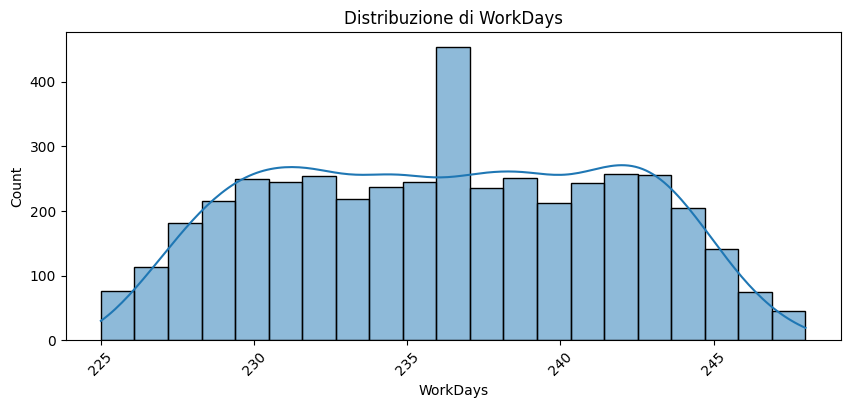

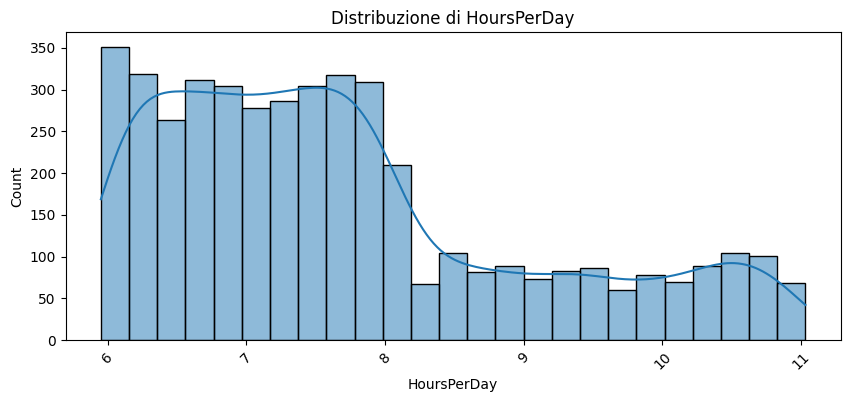

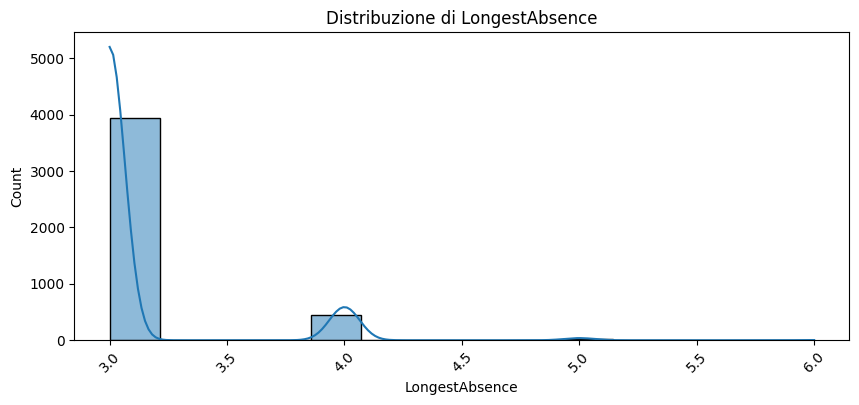

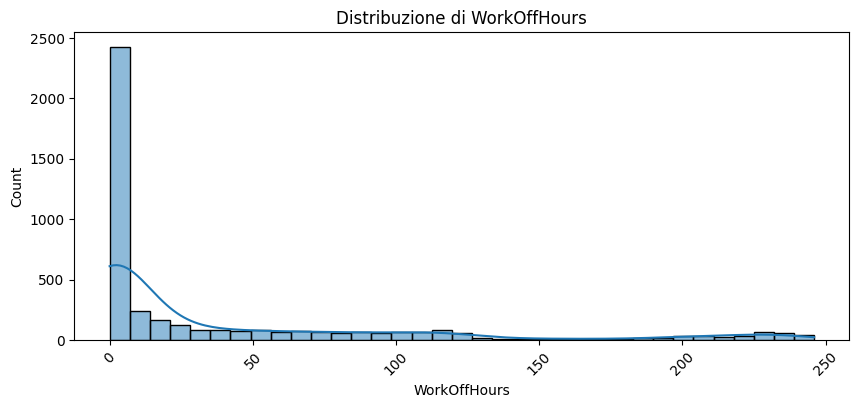

In [35]:
for column in badge.columns.drop('EmployeeID'):
    plt.figure(figsize=(10, 4))
    sns.histplot(badge[column], kde=True)
    plt.title(f'Distribuzione di {column}')
    plt.xticks(rotation=45)
    plt.show()

In [36]:
df = pd.merge(df, badge, on='EmployeeID', how='inner')
df

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeID,Gender,JobLevel,...,YearsWithCurrManager,JobInvolvement,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,WorkDays,HoursPerDay,LongestAbsence,WorkOffHours
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,Female,1,...,0,3,3,3.0,4.0,2.0,232,7.373651,3,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,2,Female,1,...,4,2,4,3.0,2.0,4.0,236,7.718969,3,0
2,32,No,Travel_Frequently,Research & Development,17,4,Other,3,Male,4,...,3,3,3,2.0,2.0,1.0,242,7.013240,3,1
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,4,Male,3,...,5,2,3,4.0,4.0,3.0,235,7.193678,4,0
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,5,Male,1,...,4,3,3,4.0,1.0,3.0,245,8.006175,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4295,29,No,Travel_Rarely,Sales,4,3,Other,4405,Female,2,...,5,2,3,3.0,4.0,3.0,243,7.292814,3,0
4296,42,No,Travel_Rarely,Research & Development,5,4,Medical,4406,Female,1,...,2,3,3,4.0,1.0,3.0,243,8.522277,3,0
4297,29,No,Travel_Rarely,Research & Development,2,4,Medical,4407,Male,1,...,2,2,3,4.0,4.0,3.0,241,6.092954,3,99
4298,25,No,Travel_Rarely,Research & Development,25,2,Life Sciences,4408,Male,2,...,2,3,4,1.0,3.0,3.0,231,7.706632,3,0


##Predizione e utilizzo dei modelli di Machine Learning

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score, precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
from xgboost import XGBClassifier

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4300 entries, 0 to 4299
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Age                      4300 non-null   int64   
 1   Attrition                4300 non-null   category
 2   BusinessTravel           4300 non-null   object  
 3   Department               4300 non-null   object  
 4   DistanceFromHome         4300 non-null   int64   
 5   Education                4300 non-null   int64   
 6   EducationField           4300 non-null   object  
 7   EmployeeID               4300 non-null   int64   
 8   Gender                   4300 non-null   object  
 9   JobLevel                 4300 non-null   int64   
 10  JobRole                  4300 non-null   object  
 11  MaritalStatus            4300 non-null   object  
 12  MonthlyIncome            4300 non-null   int64   
 13  NumCompaniesWorked       4300 non-null   float64 
 14  PercentS

In [39]:
df.describe()

,Age,DistanceFromHome,Education,EmployeeID,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,...,YearsWithCurrManager,JobInvolvement,PerformanceRating,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,WorkDays,HoursPerDay,LongestAbsence,WorkOffHours
count,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,...,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000,4300.000000
mean,36.926977,9.197907,2.913256,2211.695116,2.066977,65059.844186,2.690000,15.210698,0.795349,11.285116,...,4.132558,2.728837,3.153953,2.723953,2.724884,2.761163,236.270698,7.702877,3.116279,40.157442
std,9.146517,8.097059,1.024774,1272.117692,1.106633,47045.398914,2.495764,3.662777,0.853534,7.790052,...,3.565831,0.710769,0.360946,1.093802,1.101875,0.707800,5.494883,1.342717,0.347074,64.926925
min,18.000000,1.000000,1.000000,1.000000,1.000000,10090.000000,0.000000,11.000000,0.000000,0.000000,...,0.000000,1.000000,3.000000,1.000000,1.000000,1.000000,225.000000,5.950504,3.000000,0.000000
25%,30.000000,2.000000,2.000000,1110.750000,1.000000,29260.000000,1.000000,12.000000,0.000000,6.000000,...,2.000000,2.000000,3.000000,2.000000,2.000000,2.000000,232.000000,6.666876,3.000000,0.000000
50%,36.000000,7.000000,3.000000,2215.500000,2.000000,49360.000000,2.000000,14.000000,1.000000,10.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,236.000000,7.407506,3.000000,4.000000
75%,43.000000,14.000000,4.000000,3314.250000,3.000000,83802.500000,4.000000,18.000000,1.000000,15.000000,...,7.000000,3.000000,3.000000,4.000000,4.000000,3.000000,241.000000,8.380738,3.000000,58.000000
max,60.000000,29.000000,5.000000,4409.000000,5.000000,199990.000000,9.000000,25.000000,3.000000,40.000000,...,17.000000,4.000000,4.000000,4.000000,4.000000,4.000000,248.000000,11.030960,6.000000,246.000000


In [40]:
cat_features = df.select_dtypes(include=['object', 'category']).columns.drop(['Attrition'])
num_features = df.select_dtypes(include=['int64', 'float64']).columns.drop(['EmployeeID'])

##One Hot Encoder e Normalizzazione

In [41]:
encoder = OneHotEncoder()
scaler = StandardScaler()

cat_encoded = pd.DataFrame(encoder.fit_transform(df[cat_features]).toarray(), columns=encoder.get_feature_names_out(cat_features))
num_scaled = pd.DataFrame(scaler.fit_transform(df[num_features]), columns=num_features)

X = pd.concat([cat_encoded, num_scaled], axis=1)
y = df['Attrition']

In [42]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4300 entries, 0 to 4299
Data columns (total 48 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   BusinessTravel_Non-Travel          4300 non-null   float64
 1   BusinessTravel_Travel_Frequently   4300 non-null   float64
 2   BusinessTravel_Travel_Rarely       4300 non-null   float64
 3   Department_Human Resources         4300 non-null   float64
 4   Department_Research & Development  4300 non-null   float64
 5   Department_Sales                   4300 non-null   float64
 6   EducationField_Human Resources     4300 non-null   float64
 7   EducationField_Life Sciences       4300 non-null   float64
 8   EducationField_Marketing           4300 non-null   float64
 9   EducationField_Medical             4300 non-null   float64
 10  EducationField_Other               4300 non-null   float64
 11  EducationField_Technical Degree    4300 non-null   float

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
y_train = y_train.map({'Yes': 1, 'No': 0}).astype(int)
y_test = y_test.map({'Yes': 1, 'No': 0}).astype(int)

##Creazione dei modelli

In [44]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, random_state=42)
}

predictions = {}
for name, model in models.items():
  model.fit(X_train, y_train)
  predictions[name] = model.predict(X_test)

In [45]:
def display_metrics(y_test, y_pred, model_name):
  print('Nome modello: ', model_name)
  print('Confusion Matrix: \n', confusion_matrix(y_test, y_pred))
  print('Classification report: \n', classification_report(y_test, y_pred))
  print('\n')

for name, y_pred in predictions.items():
  display_metrics(y_test, y_pred, name)

Nome modello:  LogisticRegression
Confusion Matrix: 
 [[1052   29]
 [ 158   51]]
Classification report: 
               precision    recall  f1-score   support

           0       0.87      0.97      0.92      1081
           1       0.64      0.24      0.35       209

    accuracy                           0.86      1290
   macro avg       0.75      0.61      0.64      1290
weighted avg       0.83      0.86      0.83      1290



Nome modello:  SVM
Confusion Matrix: 
 [[1081    0]
 [ 111   98]]
Classification report: 
               precision    recall  f1-score   support

           0       0.91      1.00      0.95      1081
           1       1.00      0.47      0.64       209

    accuracy                           0.91      1290
   macro avg       0.95      0.73      0.79      1290
weighted avg       0.92      0.91      0.90      1290



Nome modello:  KNN
Confusion Matrix: 
 [[1043   38]
 [ 145   64]]
Classification report: 
               precision    recall  f1-score   support


Da queste simulazioni si evince che i modelli che si comportano meglio sono XGBoost e RandomForest, quelli che si comportano peggio, seppur con metriche più che buone, sono LogisticRegression e SVM.

In particolare XGBoost e RandomForest arrivano ad un'accuracy del 98/99%, mentre LogisticRegression ha l'86% e SVM il 91%.

Utilizziamo ora anche un altra metrica di performance: la ROC curve.

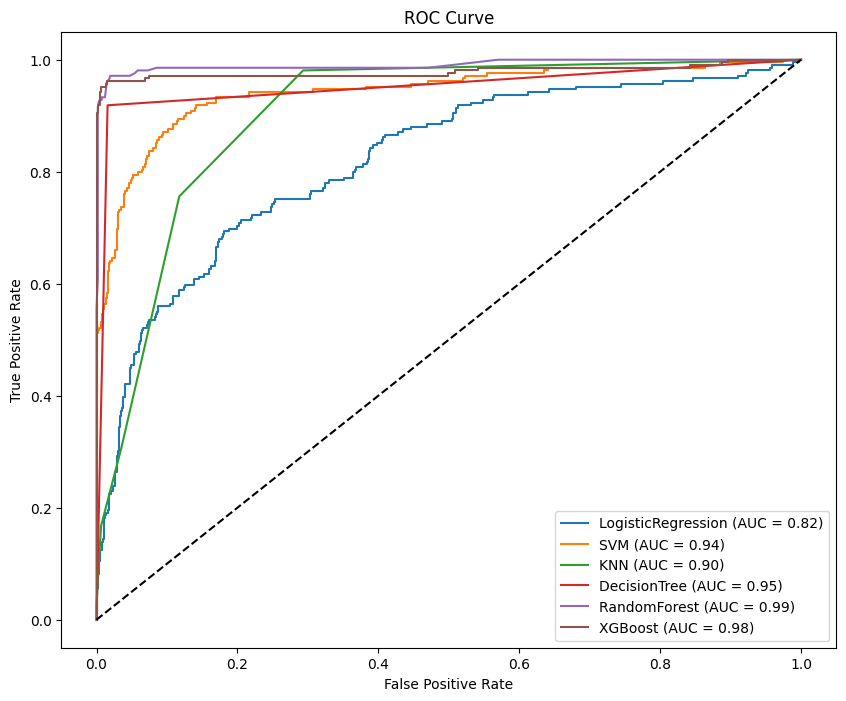

In [46]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

plt.figure(figsize=(10,8))

for name, model in models.items():
  if hasattr(model, "predict_proba"):
    y_proba = model.predict_proba(X_test)[:, 1]
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    plt.plot(false_positive_rate, true_positive_rate, label=f"{name} (AUC = {roc_auc:.2f})")


plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

XGBoost e RandomForest hanno le migliori performance anche sotto questa metrica. Riescono a identificare correttamente un'alta percentuale di veri positivi mantenendo basso il tasso di falsi positivi.

Cerchiamo ora di capire quali sono i principali effetti che causano il turnover (dovrebbero essere coerenti con le analisi fatte in precedenza con i grafici a violino).

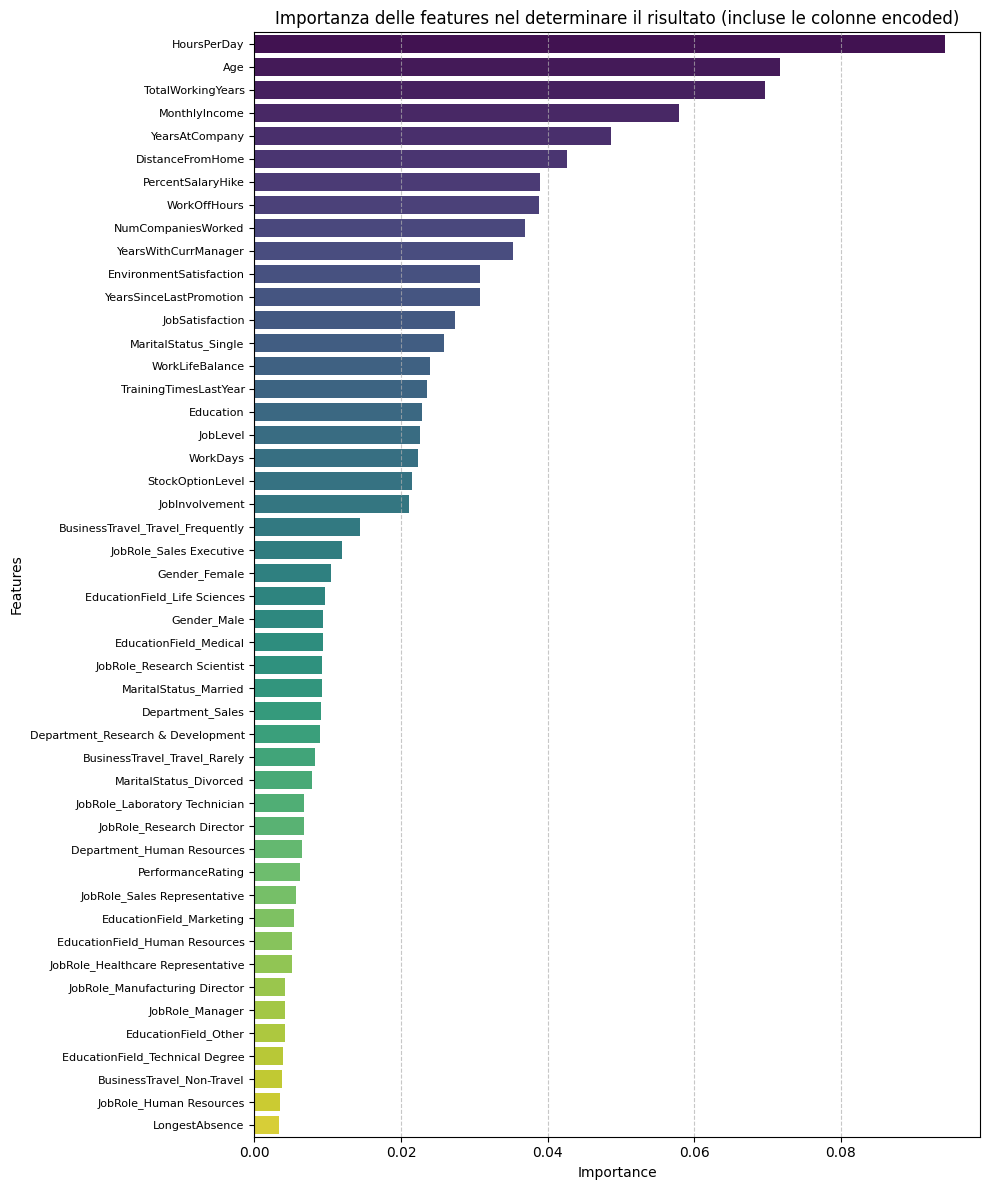

In [47]:
best_rf = models["RandomForest"]
feature_importance = best_rf.feature_importances_
features = X.columns

feat_importances_rf_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
feat_importances_rf_df = feat_importances_rf_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 12))
sns.barplot(data = feat_importances_rf_df, y="Feature", x="Importance", hue="Feature", palette="viridis", legend=False)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.yticks(fontsize=8)
plt.title("Importanza delle features nel determinare il risultato (incluse le colonne encoded)")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

Valutazione dell'importanza delle feature in base al metodo SHAP.

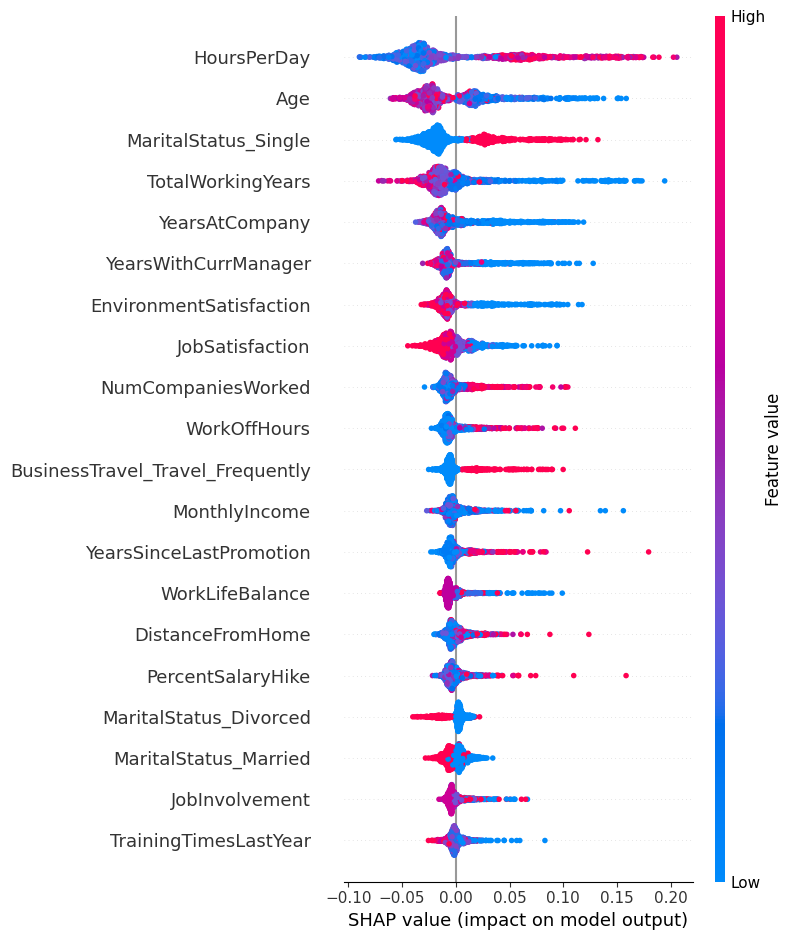

In [48]:
import shap
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values[:, :, 1], X_test.values, feature_names=X_test.columns)
plt.show()

Il Summary Plot conferma che la variabile HoursPerDay è il predittore più influente in assoluto. La distribuzione di punti rossi (che indicano un alto numero di ore lavorate) si estende decisamente verso destra (valori SHAP positivi), dimostrando una forte correlazione diretta con l'aumento della probabilità di abbandono. Questo valida l'ipotesi che il sovraccarico di lavoro sia la motivazione principale del turnover.

Al contrario, per le variabili Age e TotalWorkingYears, si osserva che sono i valori bassi (punti blu) a spingere la predizione verso l'attrition. Ciò indica che i dipendenti più giovani e con meno esperienza sono strutturalmente più a rischio rispetto ai colleghi senior. I

Lo studio conferma l'efficacia dei modelli Ensemble (Random Forest e XGBoost) che, con un'accuratezza superiore al 98%, superano i metodi statistici tradizionali. L'ingegnerizzazione dei log temporali è risultata decisiva: il carico di lavoro (HoursPerDay) emerge come predittore di turnover più forte rispetto a molte variabili anagrafiche, mentre le assenze prolungate hanno impatto marginale. L'analisi SHAP suggerisce al management tre priorità: monitorare il rischio burnout legato agli straordinari, implementare programmi di mentorship per i profili junior e valorizzare la stabilità della leadership. Per il futuro, si propone di evolvere l'analisi da statica a temporale (Survival Analysis), di integrare dati non strutturati tramite NLP e di sviluppare dashboard operative per un monitoraggio in tempo reale.